## Moein Abdollahi Sarvi - ComSys project

In [ ]:
import cv2
import numpy as np
from scipy.fftpack import dct
from skimage.util import view_as_blocks
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct

image = cv2.imread('input_transmission_image.jpg', cv2.IMREAD_GRAYSCALE)

def process_image(image):
    image = image.astype(np.float64)

    # Ensure the image dimensions are divisible by 8
    height, width = image.shape
    if height % 8 != 0 or width % 8 != 0:
        height = height - (height % 8)
        width = width - (width % 8)
        image = image[:height, :width]

    # Divide the image into 8x8 blocks
    blocks = view_as_blocks(image, block_shape=(8, 8))

    dct_blocks = np.zeros_like(blocks)
    for i in range(blocks.shape[0]):
        for j in range(blocks.shape[1]):
            dct_blocks[i, j] = dct(dct(blocks[i, j].T, norm='ortho').T, norm='ortho')

    min_val = dct_blocks.min()
    max_val = dct_blocks.max()
    scaled_blocks = (dct_blocks - min_val) / (max_val - min_val)

    quantization_levels = 255  
    quantized_blocks = np.round(scaled_blocks * (quantization_levels))
    quantized_blocks = quantized_blocks.astype(np.uint8)

    # Reshape to 3D array (8x8xN)
    n_blocks = quantized_blocks.shape[0] * quantized_blocks.shape[1]
    reshaped_3d = quantized_blocks.reshape(n_blocks, 8, 8)
    final_3d_array = reshaped_3d.transpose(1, 2, 0)

    print(quantized_blocks.shape)
    print(n_blocks)
    return final_3d_array

final_3d_array = process_image(image)



(170, 170, 8, 8)
28900


In [ ]:
def convert_to_bitstream(final_3d_array, N):
    # Reshape the 3D array into 64×num_blocks (flattening each 8×8 block)
    num_blocks = final_3d_array.shape[2]
    flattened_blocks = final_3d_array.reshape(64, num_blocks)

    # Determine the number of chunks
    num_chunks = num_blocks // N  # Number of full chunks
    remainder = num_blocks % N  # Remaining blocks that don’t fit in full chunks

    # Split into chunks of size 64×N
    chunks = [flattened_blocks[:, i * N: (i + 1) * N] for i in range(num_chunks)]
    
    # If there are leftover blocks, add them as a smaller chunk
    if remainder > 0:
        chunks.append(flattened_blocks[:, num_chunks * N:])

    # Convert each chunk to a bitstream (each value stored as 8-bit binary)
    bitstream_chunks = [chunk.astype(np.uint8).tobytes() for chunk in chunks]

    return bitstream_chunks

N = 10  # chunk size
bitstream = convert_to_bitstream(final_3d_array, N)


print(f"Generated {len(bitstream)} chunks of bitstream data.")

# Here we have some chunks of data, each chunk is consists of 64 * N numbers (64 because each 
# block is 8*8 and N because each chunk consists of N blocks. these 64 * N numbers are 
# quantized values and can be represented by 8 bit (1 Byte). so each chunk is 64 * N Bytes!)


Generated 2890 chunks of bitstream data.


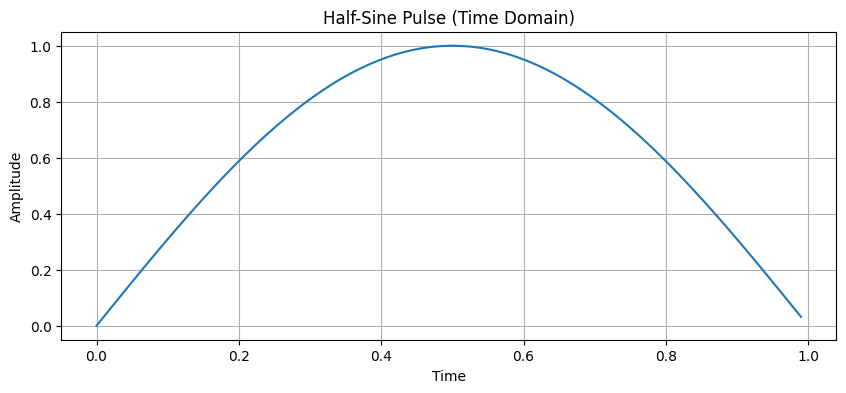

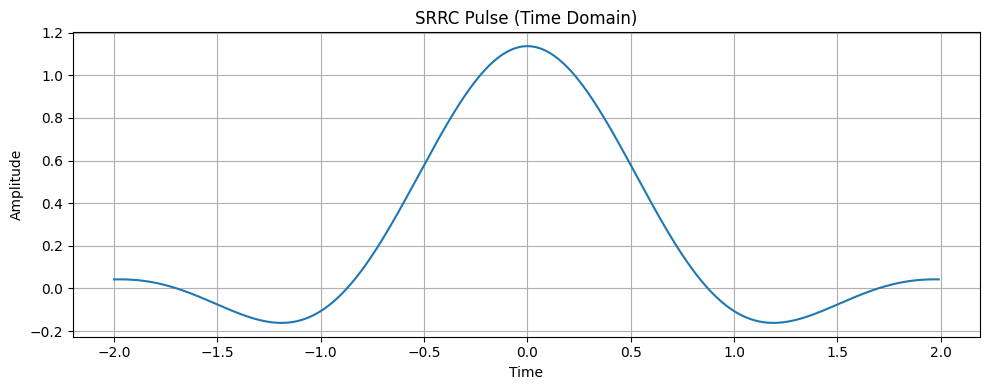

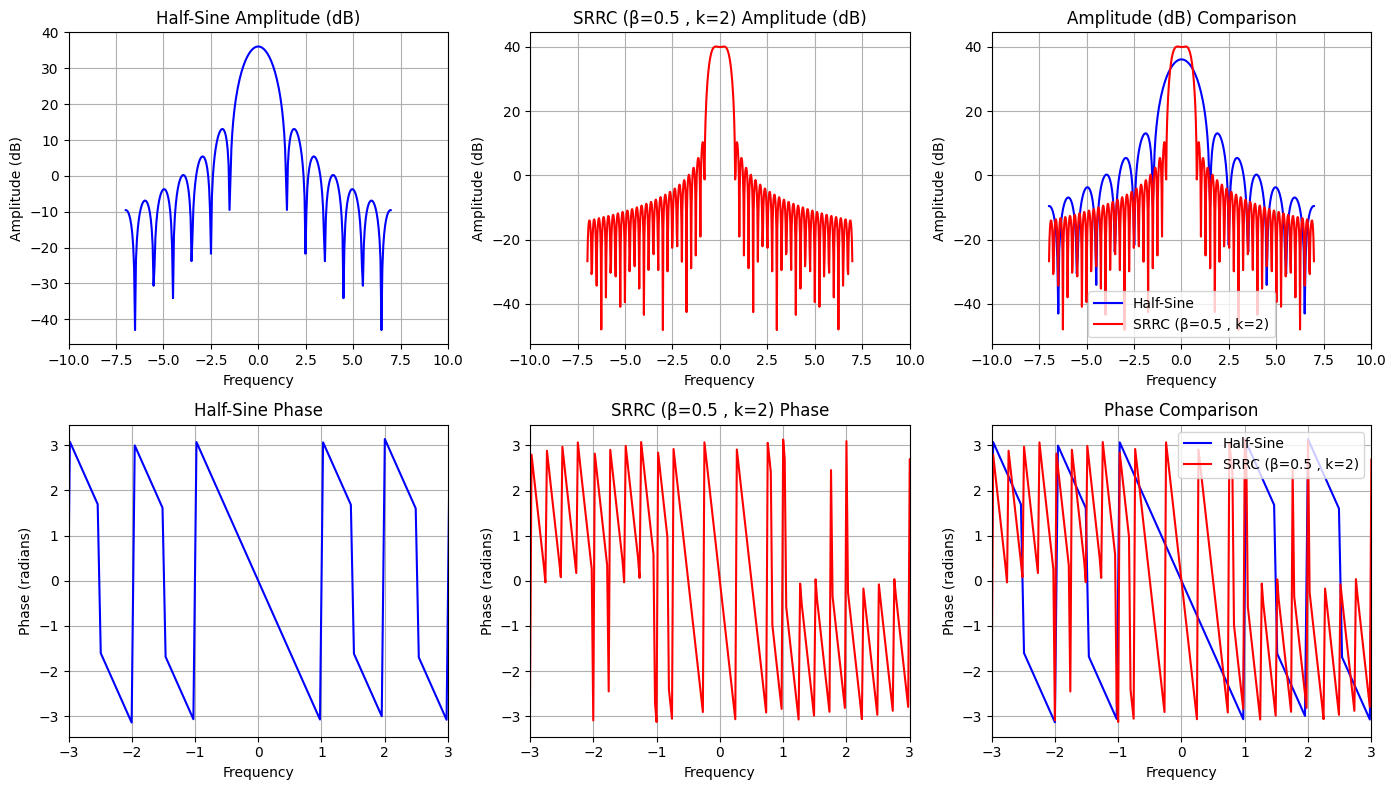

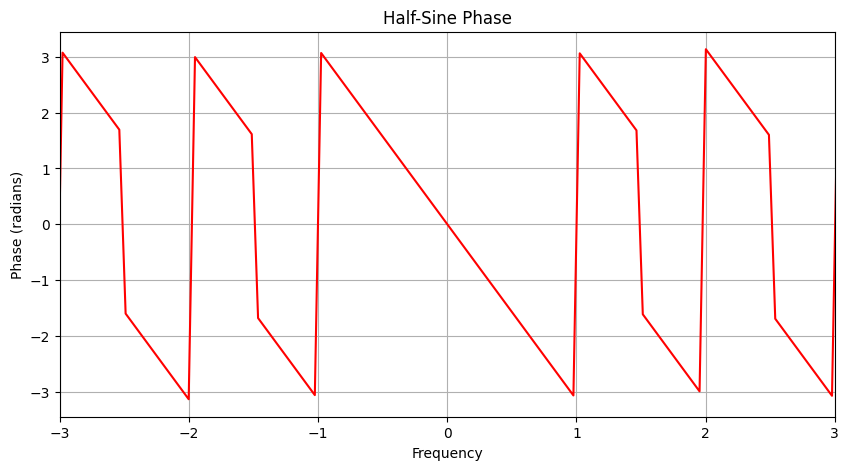

In [4]:
def half_sine_pulse(t, T):
    """ Half-sine pulse over 0 <= t <= T. """
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)

def srrc_pulse(t, T, beta):
    """ Square-root raised-cosine pulse over -K*T <= t <= K*T. """
    eps  = 1e-12
    srrc = np.zeros_like(t)
    for i, ti in enumerate(t):
        tau = ti / T
        num = np.sin(np.pi*(1-beta)*tau) + 4*beta*tau*np.cos(np.pi*(1+beta)*tau)
        den = np.pi*tau * (1 - (4*beta*tau)**2)
        if abs(ti) < eps:
            # limit as t -> 0
            srrc[i] = 1 - beta + 4*beta/np.pi
        elif abs(1 - 4*beta*tau) < eps or abs(1 + 4*beta*tau) < eps:
            # approximate limit near zero denominator
            srrc[i] = (beta/np.sqrt(2))*(
                (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
                (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
            )
        else:
            srrc[i] = num / den
    return srrc

def main():
    # Parameters
    T    = 1.0       # Symbol period
    beta = 0.5       # Roll-off factor
    K    = 2         # SRRC spans -K*T to +K*T

    # Sampling for time-domain
    Fs_half = 100
    Fs_srrc = 100
    t_half  = np.linspace(0, T, Fs_half, endpoint=False)
    t_srrc  = np.linspace(-K*T, K*T, 2*K*Fs_srrc, endpoint=False)

    # Generate pulses
    half_sine = half_sine_pulse(t_half, T)
    srrc      = srrc_pulse(t_srrc, T, beta)

    # FFT parameters
    Nfft_half = 2048
    Nfft_srrc = 4096

    # Frequency responses (shifted so 0 freq is at center)
    H_half = np.fft.fftshift(np.fft.fft(half_sine, Nfft_half))
    freq_h = np.fft.fftshift(np.fft.fftfreq(Nfft_half, d=(t_half[1] - t_half[0])))

    H_srrc = np.fft.fftshift(np.fft.fft(srrc, Nfft_srrc))
    freq_s = np.fft.fftshift(np.fft.fftfreq(Nfft_srrc, d=(t_srrc[1] - t_srrc[0])))

    # Convert amplitudes to dB (avoid log(0) with a small epsilon)
    eps = 1e-12
    H_half_dB = 20*np.log10(np.abs(H_half) + eps)
    H_srrc_dB = 20*np.log10(np.abs(H_srrc) + eps)

    # Limit frequency range to [-7, 7]
    mask_h = (freq_h >= -7) & (freq_h <= 7)
    mask_s = (freq_s >= -7) & (freq_s <= 7)

    
    plt.figure(figsize=(10, 4))
    #plt.subplot(1,2,1)
    plt.plot(t_half, half_sine, label='Half-Sine')
    plt.title("Half-Sine Pulse (Time Domain)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.figure(figsize=(10, 4))
    #plt.subplot(1,2,2)
    plt.plot(t_srrc, srrc, label='SRRC (β=0.5)')
    plt.title("SRRC Pulse (Time Domain)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(14, 8))

    # (1) Amplitude in dB for Half-Sine
    plt.subplot(2,3,1)
    plt.plot(freq_h[mask_h], H_half_dB[mask_h], color='b')
    plt.title("Half-Sine Amplitude (dB)")
    plt.xlabel("Frequency")
    plt.ylabel("Amplitude (dB)")
    plt.xlim([-10, 10])
    plt.grid(True)

    # (2) Amplitude in dB for SRRC
    plt.subplot(2,3,2)
    plt.plot(freq_s[mask_s], H_srrc_dB[mask_s], color='r')
    plt.title("SRRC (β=0.5 , k=2) Amplitude (dB)")
    plt.xlabel("Frequency")
    plt.ylabel("Amplitude (dB)")
    plt.xlim([-10, 10])
    plt.grid(True)

    # (3) Amplitude in dB - both on same plot
    plt.subplot(2,3,3)
    plt.plot(freq_h[mask_h], H_half_dB[mask_h], label='Half-Sine', color='b')
    plt.plot(freq_s[mask_s], H_srrc_dB[mask_s], label='SRRC (β=0.5 , k=2)', color='r')
    plt.title("Amplitude (dB) Comparison")
    plt.xlabel("Frequency")
    plt.ylabel("Amplitude (dB)")
    plt.legend()
    plt.xlim([-10, 10])
    plt.grid(True)

    # (4) Phase of Half-Sine
    plt.subplot(2,3,4)
    plt.plot(freq_h[mask_h], np.angle(H_half[mask_h]), color='b')
    plt.title("Half-Sine Phase")
    plt.xlabel("Frequency")
    plt.ylabel("Phase (radians)")
    plt.xlim([-3, 3])
    plt.grid(True)

    # (5) Phase of SRRC
    plt.subplot(2,3,5)
    plt.plot(freq_s[mask_s], np.angle(H_srrc[mask_s]), color='r')
    plt.title("SRRC (β=0.5 , k=2) Phase")
    plt.xlabel("Frequency")
    plt.ylabel("Phase (radians)")
    plt.xlim([-3, 3])
    plt.grid(True)

    # (6) Phase comparison
    plt.subplot(2,3,6)
    plt.plot(freq_h[mask_h], np.angle(H_half[mask_h]), label='Half-Sine', color='b')
    plt.plot(freq_s[mask_s], np.angle(H_srrc[mask_s]), label='SRRC (β=0.5 , k=2)', color='r')
    plt.title("Phase Comparison")
    plt.xlabel("Frequency")
    plt.ylabel("Phase (radians)")
    plt.legend()
    plt.xlim([-3, 3])
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(freq_h[mask_h], np.angle(H_half[mask_h]), color='r')
    plt.title("Half-Sine Phase")
    plt.xlabel("Frequency")
    plt.ylabel("Phase (radians)")
    plt.xlim([-3, 3])
    plt.grid(True)

if __name__ == "__main__":
    main()


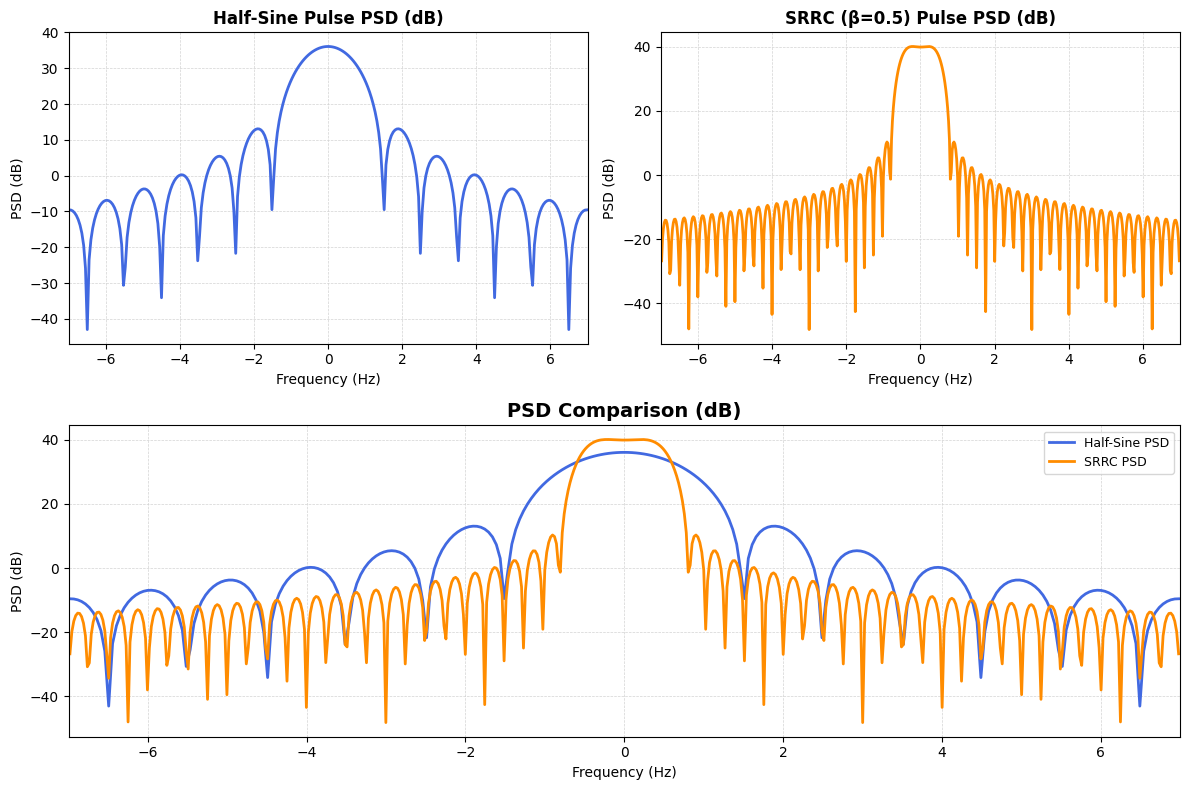

In [7]:
T_b = 1.0  
T = 1.0  
beta = 0.5
K = 2  

fs_half = 100
fs_srrc = 100
t_half = np.linspace(0, T, fs_half, endpoint=False)
t_srrc = np.linspace(-K*T, K*T, 2*K*fs_srrc, endpoint=False)

half_sine = half_sine_pulse(t_half, T)
srrc_out = srrc_pulse(t_srrc, T, beta)

Nfft_half = 2048
Nfft_srrc = 4096

H_half = np.fft.fftshift(np.fft.fft(half_sine, Nfft_half))
freq_h = np.fft.fftshift(np.fft.fftfreq(Nfft_half, d=(t_half[1]-t_half[0])))

H_srrc = np.fft.fftshift(np.fft.fft(srrc_out, Nfft_srrc))
freq_s = np.fft.fftshift(np.fft.fftfreq(Nfft_srrc, d=(t_srrc[1]-t_srrc[0])))

eps = 1e-12
PSD_half = np.abs(H_half)**2  
PSD_srrc = np.abs(H_srrc)**2

PSD_half_dB = 10 * np.log10(PSD_half + eps)
PSD_srrc_dB = 10 * np.log10(PSD_srrc + eps)

mask_h = (freq_h >= -7) & (freq_h <= 7)
mask_s = (freq_s >= -7) & (freq_s <= 7)

# --- Enhanced plots ---
plt.figure(figsize=(12, 8))

# Half-Sine PSD
plt.subplot(2, 2, 1)
plt.plot(freq_h[mask_h], PSD_half_dB[mask_h], color='royalblue', linewidth=2)
plt.title("Half-Sine Pulse PSD (dB)", fontsize=12, fontweight='bold')
plt.xlabel("Frequency (Hz)", fontsize=10)
plt.ylabel("PSD (dB)", fontsize=10)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.xlim([-7, 7])

# SRRC PSD
plt.subplot(2, 2, 2)
plt.plot(freq_s[mask_s], PSD_srrc_dB[mask_s], color='darkorange', linewidth=2)
plt.title("SRRC (β=0.5) Pulse PSD (dB)", fontsize=12, fontweight='bold')
plt.xlabel("Frequency (Hz)", fontsize=10)
plt.ylabel("PSD (dB)", fontsize=10)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.xlim([-7, 7])

# Comparison plot
plt.subplot(2, 1, 2)
plt.plot(freq_h[mask_h], PSD_half_dB[mask_h], label="Half-Sine PSD", color='royalblue', linewidth=2)
plt.plot(freq_s[mask_s], PSD_srrc_dB[mask_s], label="SRRC PSD", color='darkorange', linewidth=2)
plt.title("PSD Comparison (dB)", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Hz)", fontsize=10)
plt.ylabel("PSD (dB)", fontsize=10)
plt.legend(loc="upper right", fontsize=9)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.xlim([-7, 7])

# Make layout tighter and more readable
plt.tight_layout()
plt.show()


## generatng Waveform for 10 randomely generated bits

[0 1 1 0 1 1 1 1 1 1]


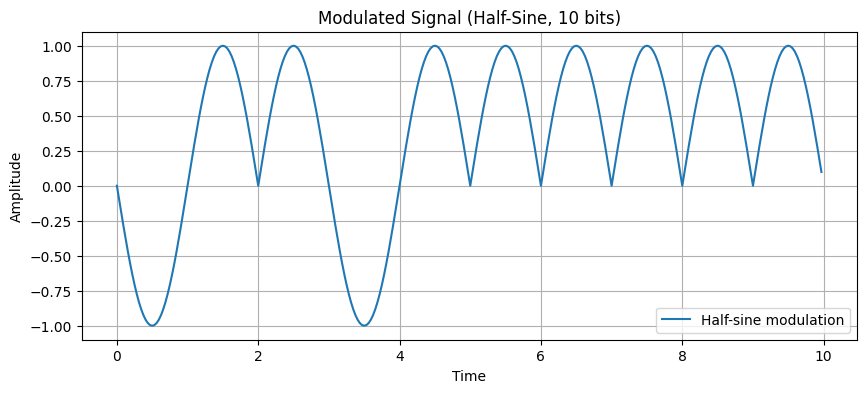

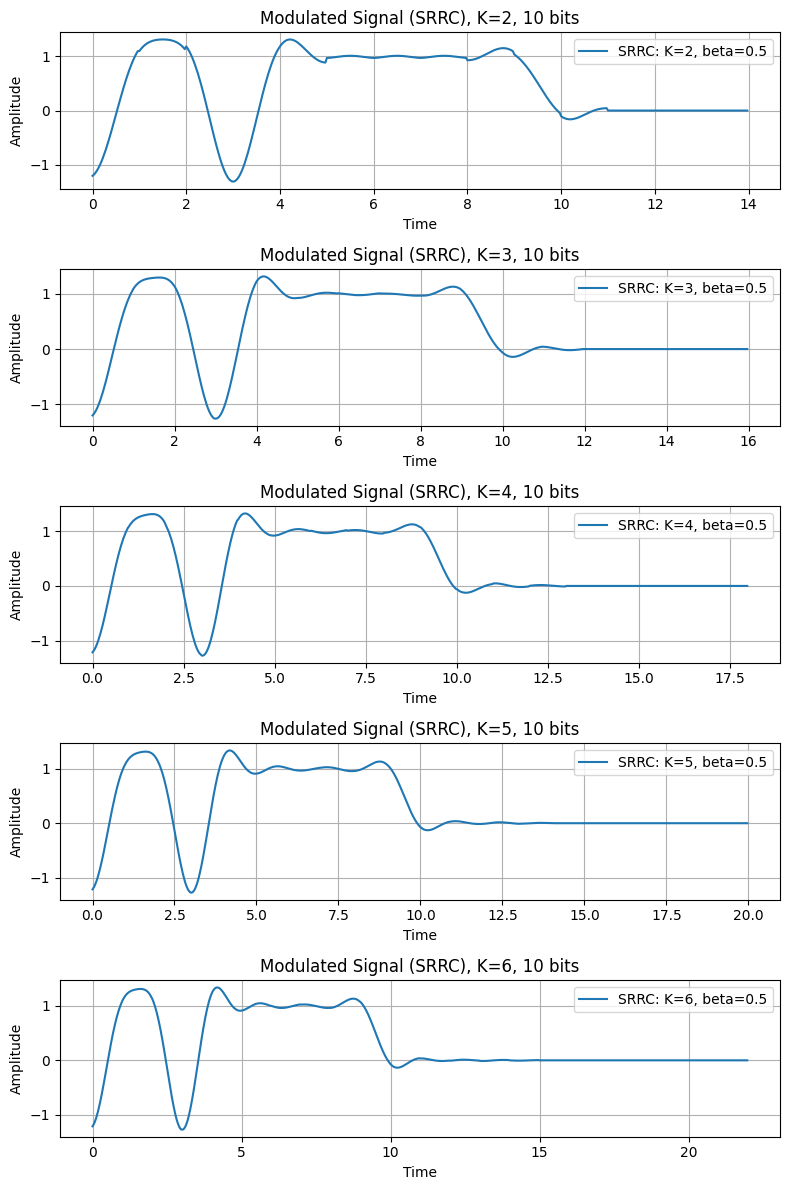

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def generate_random_bits(num_bits=10):
    return np.random.randint(0, 2, size=num_bits)

def polar_mapping(bits):
    return 2*bits - 1

def half_sine_pulse(t):
    out = np.zeros_like(t)
    mask = (t >= 0) & (t <= 1)
    out[mask] = np.sin(np.pi * t[mask])
    return out

def srrc_pulse(t, beta=0.5):
    eps = 1e-12
    out = np.zeros_like(t)
    for i, ti in enumerate(t):
        if abs(ti) < eps:
            # Limit as t->0
            out[i] = 1 - beta + 4*beta/np.pi
        else:
            num = (np.sin(np.pi*(1-beta)*ti) +
                   4*beta*ti*np.cos(np.pi*(1+beta)*ti))
            den = np.pi * ti * (1 - (4*beta*ti)**2)
            if abs(den) < eps:
                # Approx. special-case limit
                out[i] = (beta/np.sqrt(2)) * (
                    (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
                    (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
                )
            else:
                out[i] = num / den
    return out

def build_signal(bits_polar, pulse_name='half', K=2, beta=0.5):
    num_bits = len(bits_polar)
    sps_half = 32  # 32 samples per bit for half-sine

    if pulse_name == 'half':
        # Half-sine: total time is num_bits
        dt = 1.0 / sps_half
        t_end = num_bits  # from 0 up to num_bits
        t = np.arange(0, t_end, dt)
        x = np.zeros_like(t)
        # Build
        for i, b in enumerate(bits_polar):
            # shift the pulse by i
            shifted_t = t - i
            p_vals = half_sine_pulse(shifted_t)
            x += b * p_vals

        return t, x

    else:
        sps_srrc = 32
        dt = 1.0 / sps_srrc
        t_end = num_bits + 2*K  
        t = np.arange(0, t_end, dt)
        x = np.zeros_like(t)

        # Precompute the SRRC pulse for times in [-K, K].
        pulse_t = np.linspace(-K, K, 2*K*sps_srrc, endpoint=False)
        p_srrc = srrc_pulse(pulse_t, beta=beta)

        # For each bit i, center the pulse at t=i
        for i, b in enumerate(bits_polar):
            for idx_time, tj in enumerate(t):
                tau = tj - i  
                frac = (tau + K) / (2*K)  
                idx_p = int(np.floor(frac * (2*K*sps_srrc)))
                if 0 <= idx_p < len(p_srrc):
                    x[idx_time] += b * p_srrc[idx_p]
        return t, x

def main():
    np.random.seed(0)      # For reproducible bits
    bits_01 = generate_random_bits(10)
    #bits_01 = np.array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])
    print(bits_01)
    bits_polar = polar_mapping(bits_01)

    # 1) Half-sine
    t_half, x_half = build_signal(bits_polar, pulse_name='half')
    plt.figure(figsize=(10,4))
    plt.plot(t_half, x_half, label='Half-sine modulation')
    plt.title("Modulated Signal (Half-Sine, 10 bits)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2) SRRC for K=2..6, same bits. 
    #    We'll show them in separate subplots for comparison.
    k_values = [2, 3, 4, 5, 6]
    plt.figure(figsize=(8, 12))
    
    for i, k in enumerate(k_values):
        t_srrc, x_srrc = build_signal(bits_polar, pulse_name='srrc', K=k, beta=0.5)
        plt.subplot(len(k_values), 1, i+1)
        plt.plot(t_srrc, x_srrc, label=f"SRRC: K={k}, beta=0.5")
        plt.title(f"Modulated Signal (SRRC), K={k}, 10 bits")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


## Eye Diagram (Without Passing Through Channel)

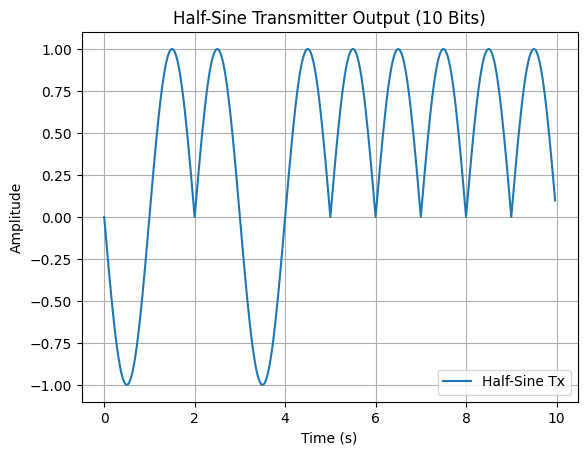

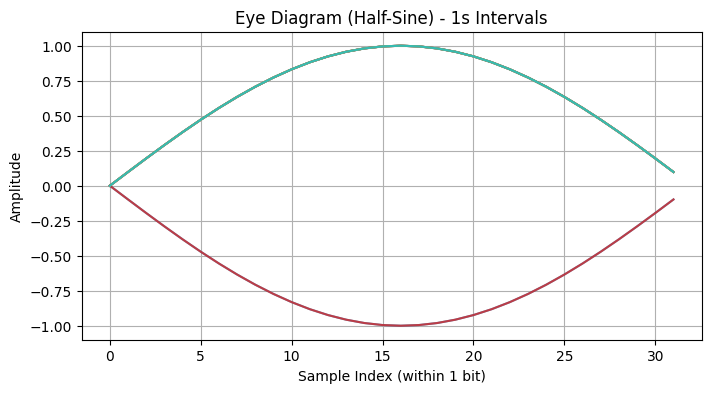

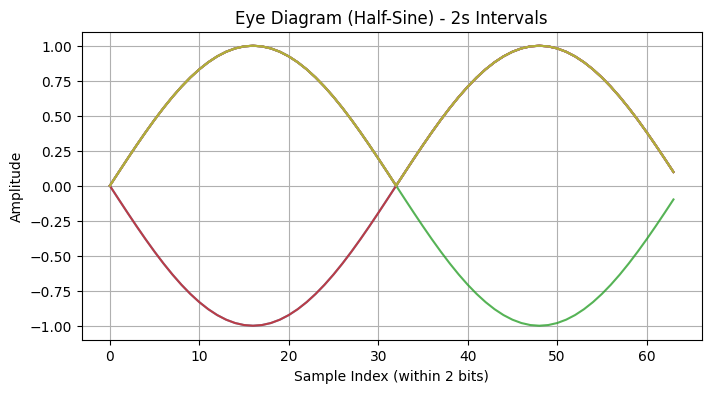

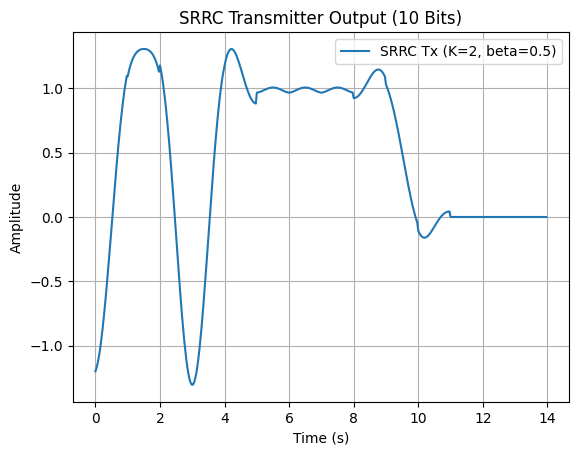

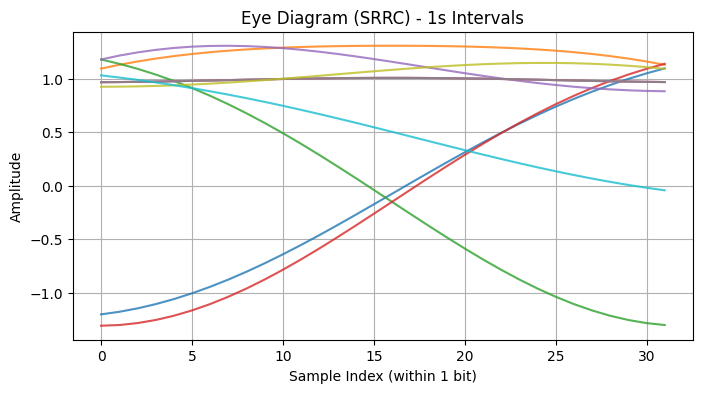

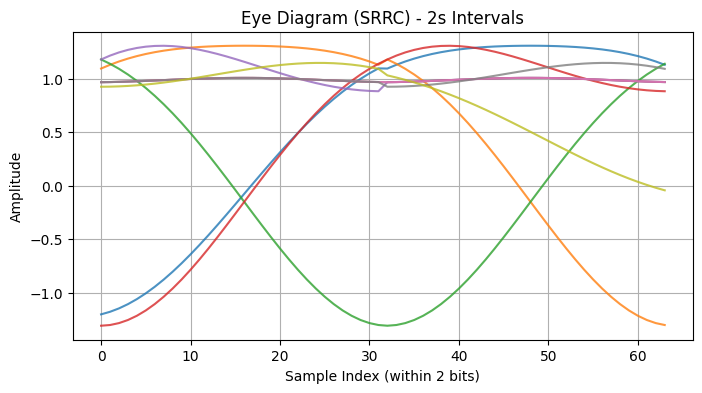

In [10]:
def srrc_pulse_time_domain(t, T=1.0, beta=0.5, eps=1e-12):
    """
    Square-Root Raised Cosine (SRRC) pulse at time 't'.
    Handles special cases near t=0 and t=±T/(4*beta).
    """
    if abs(t) < eps:
        return 1.0 - beta + 4*beta/np.pi
    
    # T/(4*beta) case
    critical = T/(4*beta)
    if abs(abs(t) - critical) < eps:
        return (beta / np.sqrt(2)) * (
            (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
            (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
        )
    
    # Generic formula
    num = (np.sin(np.pi*(1-beta)*t/T)
           + 4*beta*(t/T)*np.cos(np.pi*(1+beta)*t/T))
    den = (np.pi*(t/T)*(1 - (4*beta*(t/T))**2))
    return num / (den + eps)

def half_sine_pulse_time_domain(t, T=1.0):
    """
    p_half(t) = sin(pi*t/T) for 0 <= t <= T, else 0
    """
    if 0 <= t <= T:
        return np.sin(np.pi * t / T)
    else:
        return 0.0

def build_half_sine_transmit_signal(bits, sps=32):
    """
    Summation of time-shifted half-sine pulses (each 1 second wide).
    bits: array of +1/-1
    sps: samples per bit
    Returns: t_axis, x
    """
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    for i, b in enumerate(bits):
        for idx, tj in enumerate(t_axis):
            tau = tj - i
            val = half_sine_pulse_time_domain(tau, T=1.0)
            x[idx] += b * val
    
    return t_axis, x

def build_srrc_transmit_signal(bits, K=2, beta=0.5, sps=32):
    """
    Summation of time-shifted SRRC pulses spanning [-K, +K].
    bits: array of +1/-1
    Returns: t_axis, x
    """
    N = len(bits)
    dt = 1.0 / sps
    t_end = N + 2*K
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)

    pulse_len = 2*K*sps
    t_pulse = np.linspace(-K, K, pulse_len, endpoint=False)
    p_srrc = np.array([srrc_pulse_time_domain(tp, T=1.0, beta=beta) for tp in t_pulse])
    
    for i, b in enumerate(bits):
        for idx_time, tj in enumerate(t_axis):
            tau = tj - i
            frac = (tau + K) / (2.0*K)
            idx_p = int(np.floor(frac * pulse_len))
            if 0 <= idx_p < pulse_len:
                x[idx_time] += b * p_srrc[idx_p]
    
    return t_axis, x

def plot_eye_diagram_one_second(signal, sps, num_bits, title="Eye Diagram"):
    """
    Slices signal into 1-second intervals (each has sps samples).
    """
    plt.figure(figsize=(8,4))
    for i in range(num_bits):
        start = i*sps
        stop = start + sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.8)
    plt.title(title)
    plt.xlabel("Sample Index (within 1 bit)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_eye_diagram_two_seconds(signal, sps, num_bits, title="Eye Diagram - 2-second intervals"):
    plt.figure(figsize=(8,4))
    
    # We'll plot up to num_bits-1 intervals (since each 2-second slice covers 2 bits).
    for i in range(num_bits - 1):
        start = i * sps
        stop = start + 2*sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.8)
    
    plt.title(title)
    plt.xlabel("Sample Index (within 2 bits)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def main():
    np.random.seed(0)
    num_bits = 10
    bits_01 = np.random.randint(0, 2, size=num_bits)
    bits_polar = 2*bits_01 - 1
    
    sps = 32
    t_half, x_half = build_half_sine_transmit_signal(bits_polar, sps=sps)
    
    plt.figure()
    plt.plot(t_half, x_half, label="Half-Sine Tx")
    plt.title("Half-Sine Transmitter Output (10 Bits)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # Eye diagram (1-second)
    plot_eye_diagram_one_second(x_half, sps, num_bits,
                                title="Eye Diagram (Half-Sine) - 1s Intervals")
    # Eye diagram (2-second)
    plot_eye_diagram_two_seconds(x_half, sps, num_bits,
                                 title="Eye Diagram (Half-Sine) - 2s Intervals")

    K = 2
    beta = 0.5
    t_srrc, x_srrc = build_srrc_transmit_signal(bits_polar, K=K, beta=beta, sps=sps)

    plt.figure()
    plt.plot(t_srrc, x_srrc, label=f"SRRC Tx (K={K}, beta={beta})")
    plt.title("SRRC Transmitter Output (10 Bits)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Eye diagram (1-second)
    plot_eye_diagram_one_second(x_srrc, sps, num_bits,
                                title="Eye Diagram (SRRC) - 1s Intervals")
    # Eye diagram (2-second)
    plot_eye_diagram_two_seconds(x_srrc, sps, num_bits,
                                 title="Eye Diagram (SRRC) - 2s Intervals")

if __name__ == "__main__":
    main()


## Channel Impulse Response
32 samples per second as SRRC pulse and half-sine pulse

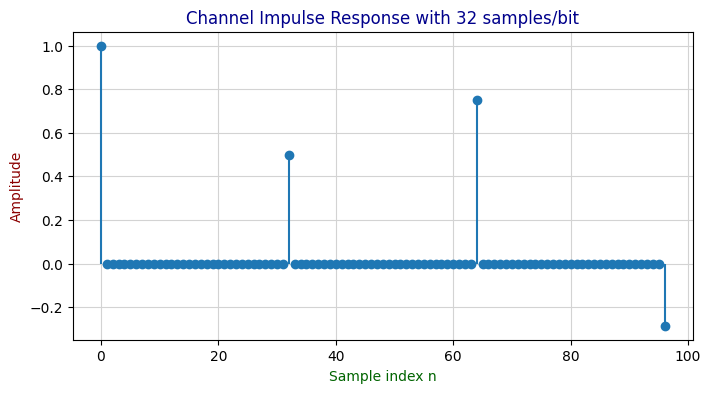

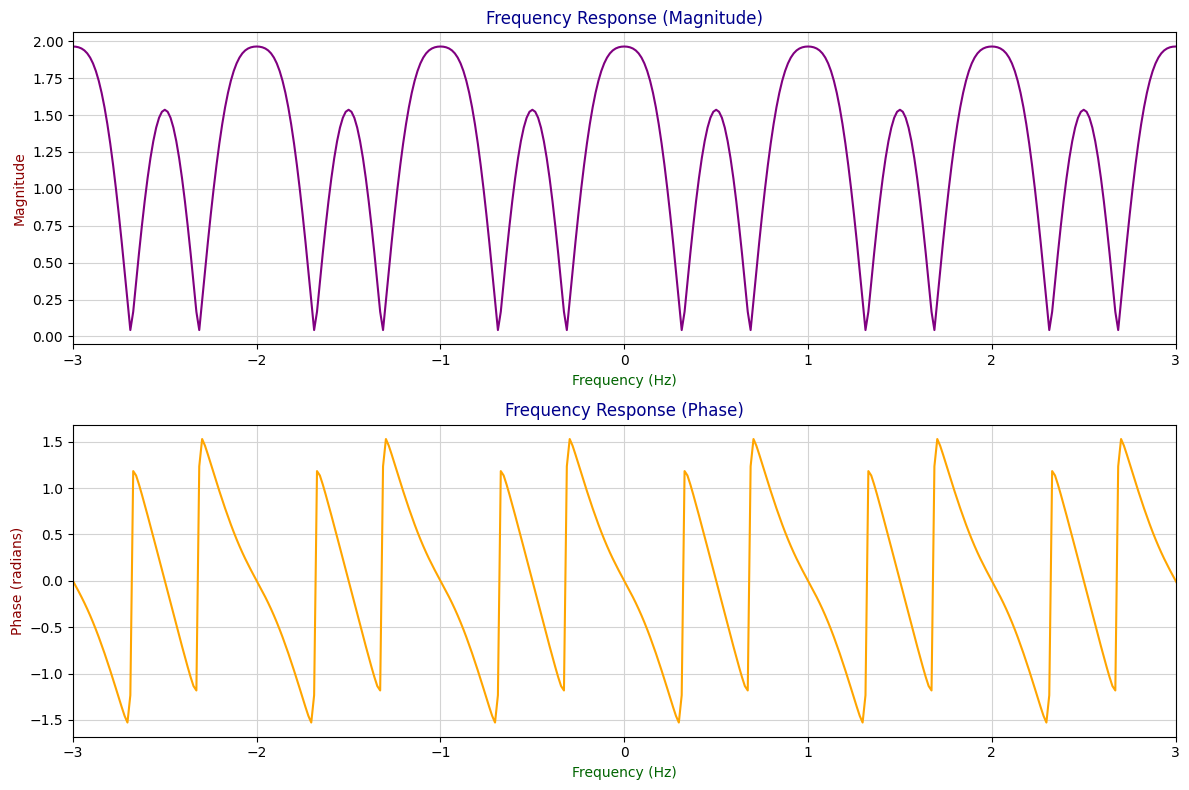

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import scipy.fftpack

def main():
    # Suppose we have 4 taps at delays of 0, 1, 2, 3 bit-intervals,
    # and each bit-interval is 32 samples.
    sps = 32  # samples per symbol (bit)
    
    # Channel taps in "bit delays":
    tap0 = 1.0
    tap1 = 0.5
    tap2 = 0.75
    tap3 = -2/7
    
    # Build the impulse response in sample terms.
    # We need an array with length at least (3*sps + 1).
    # i.e. index=0, 32, 64, 96 for the four taps.
    h_len = 3*sps + 1
    h = np.zeros(h_len)
    
    h[0]      = tap0
    h[sps]    = tap1
    h[2*sps]  = tap2
    h[3*sps]  = tap3

    # --- Plot impulse response ---
    plt.figure(figsize=(8,4))
    plt.stem(np.arange(h_len), h, basefmt=" ")
    plt.title("Channel Impulse Response with 32 samples/bit", color='darkblue')
    plt.xlabel("Sample index n", color='darkgreen')
    plt.ylabel("Amplitude", color='darkred')
    plt.grid(True, color='lightgrey')
    plt.show()
    
    # --- Frequency response using FFT ---
    # Compute FFT of the impulse response
    H = fft(h, n=2048)  # Zero-padding to 2048 points for better frequency resolution
    frequencies = fftfreq(len(H), 1 / sps)  # Frequency axis
    
    # Shift the FFT result and frequencies to arrange positive and negative frequencies
    shifted_frequencies = scipy.fftpack.fftshift(frequencies)
    shifted_H = scipy.fftpack.fftshift(H)
    
    # Magnitude and Phase of the FFT
    H_mag = np.abs(shifted_H)
    H_phase = np.angle(shifted_H)
    
    # Plot Frequency Response (Magnitude and Phase)
    plt.figure(figsize=(12, 8))
    
    # Magnitude Response Plot (in linear scale)
    plt.subplot(2,1,1)
    plt.plot(shifted_frequencies, H_mag, color='purple')
    plt.title("Frequency Response (Magnitude)", color='darkblue')
    plt.xlabel("Frequency (Hz)", color='darkgreen')
    plt.xlim([-3, 3])
    plt.ylabel("Magnitude", color='darkred')
    plt.grid(True, color='lightgrey')
    
    # Phase Response Plot (in radians)
    plt.subplot(2,1,2)
    plt.plot(shifted_frequencies, H_phase, color='orange')
    plt.title("Frequency Response (Phase)", color='darkblue')
    plt.xlabel("Frequency (Hz)", color='darkgreen')
    plt.xlim([-3, 3])
    plt.ylabel("Phase (radians)", color='darkred')
    plt.grid(True, color='lightgrey')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()




## Eye Diagram of Channel Output for 60 randomly generated bits
I used 60 bits instead of 10 bits because in this case eye diagram was more beautiful

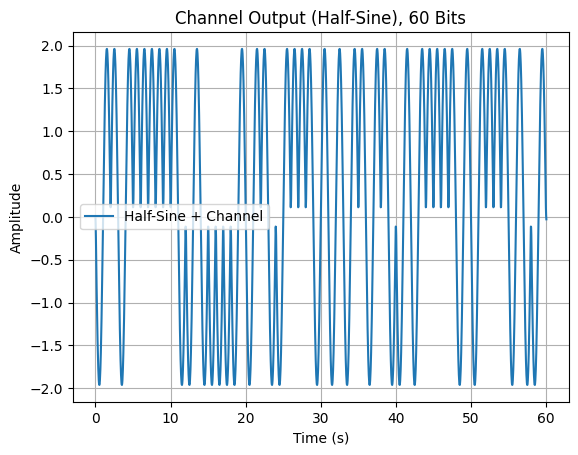

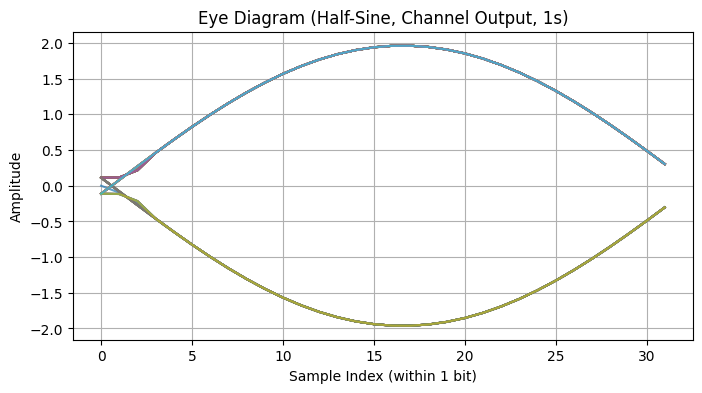

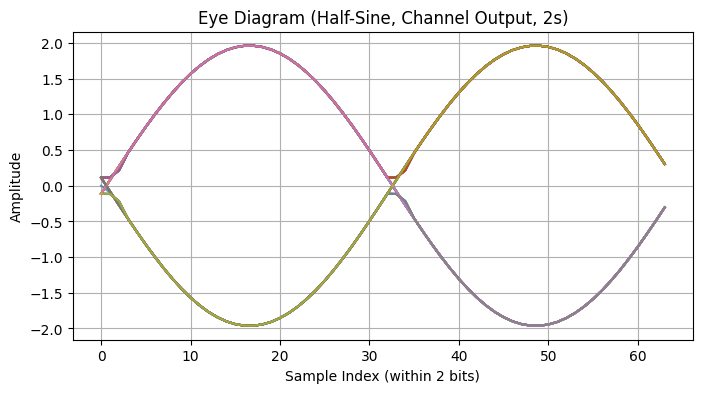

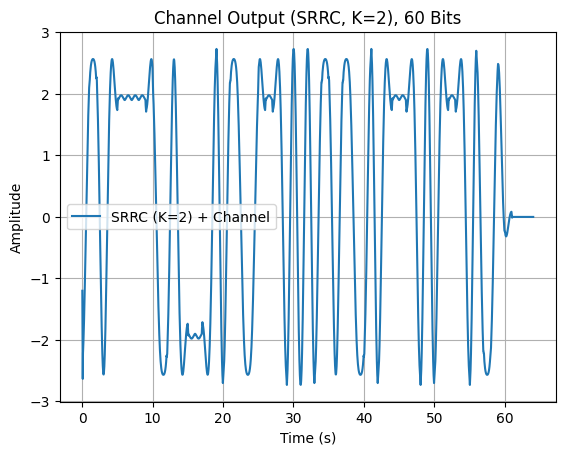

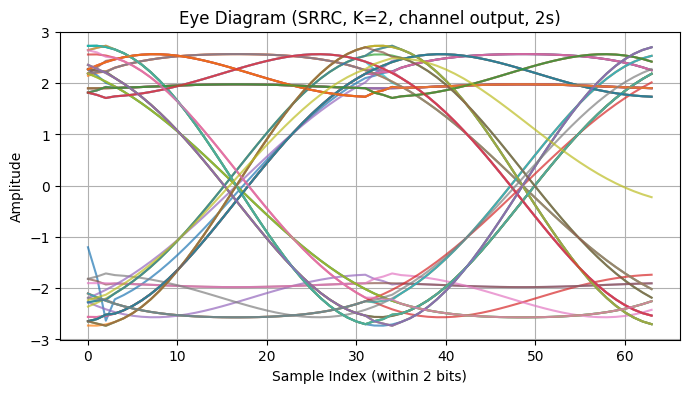

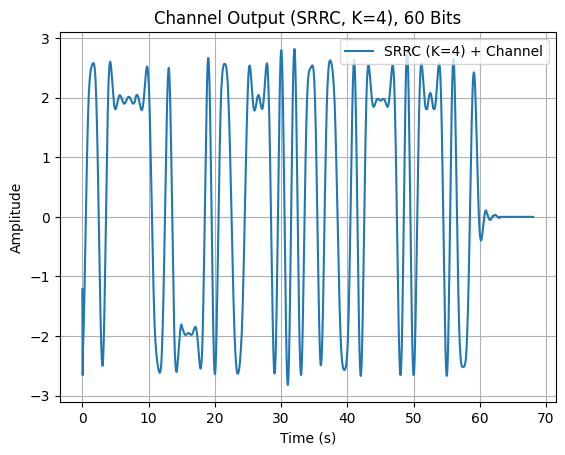

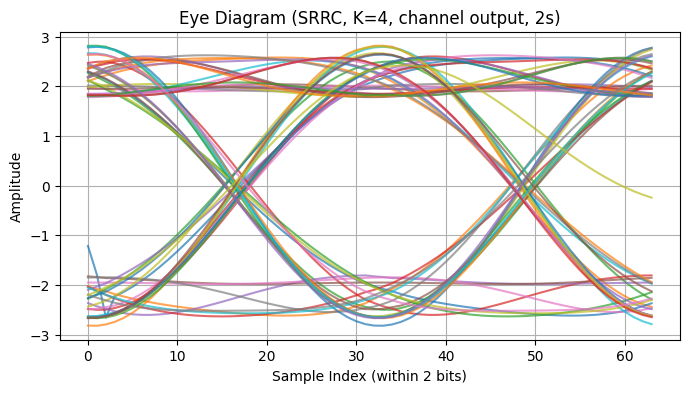

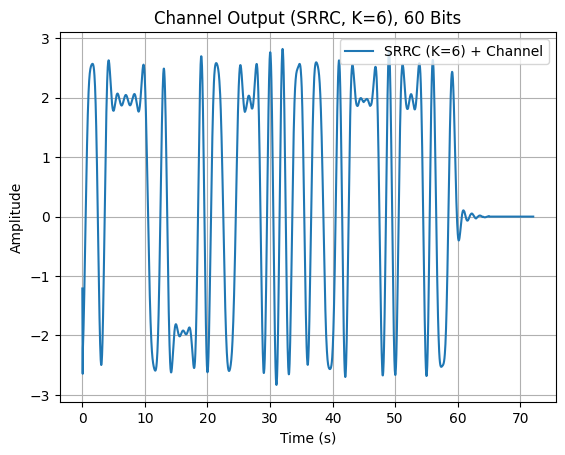

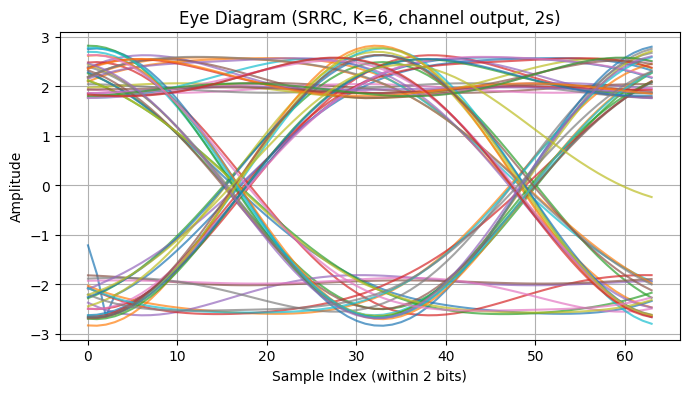

In [ ]:
# Channel Impulse Response
def get_channel_impulse_response():
    """
    4-tap channel (abstract spacing = 1 sample).
    h = [1, 1/2, 3/4, -2/7]
    """
    return np.array([1.0, 1.0/2.0, 3.0/4.0, -2.0/7.0])

# SRRC Pulse Definition
def srrc_pulse_time_domain(t, T=1.0, beta=0.5, eps=1e-6):
    if abs(t) < eps:
        return 1.0 - beta + 4*beta/np.pi
    critical = T/(4*beta)
    if abs(abs(t) - critical) < eps:
        return (beta / np.sqrt(2)) * (
            (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
            (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
        )
    num = np.sin(np.pi*(1-beta)*t/T) + 4*beta*(t/T)*np.cos(np.pi*(1+beta)*t/T)
    den = np.pi*(t/T)*(1 - (4*beta*(t/T))**2)
    return num / (den + eps)


# Half-Sine Pulse Definition
def half_sine_pulse_time_domain(t, T=1.0):
    if 0 <= t <= T:
        return np.sin(np.pi * t / T)
    return 0.0

# Build Transmit Signal: Half-Sine
def build_half_sine_transmit_signal(bits, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    for i, b in enumerate(bits):
        for idx, tj in enumerate(t_axis):
            tau = tj - i
            val = half_sine_pulse_time_domain(tau, T=1.0)
            x[idx] += b * val
    return t_axis, x

# Build Transmit Signal: SRRC
def build_srrc_transmit_signal(bits, K=2, beta=0.5, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N + 2*K
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    pulse_len = 2*K*sps
    t_pulse = np.linspace(-K, K, pulse_len, endpoint=False)
    p_srrc = np.array([srrc_pulse_time_domain(tp, T=1.0, beta=beta) for tp in t_pulse])
    
    for i, b in enumerate(bits):
        for idx_time, tj in enumerate(t_axis):
            tau = tj - i
            frac = (tau + K) / (2.0*K)
            idx_p = int(np.floor(frac * pulse_len))
            if 0 <= idx_p < pulse_len:
                x[idx_time] += b * p_srrc[idx_p]
    return t_axis, x


# Eye Diagram Helpers
def plot_eye_diagram_one_second(signal, sps, num_bits, title="Eye Diagram"):
    """
    Overlay intervals of length 'sps' (1 second).
    """
    plt.figure(figsize=(8,4))
    for i in range(num_bits):
        start = i*sps
        stop = start + sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.7)
    plt.title(title)
    plt.xlabel("Sample Index (within 1 bit)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_eye_diagram_two_seconds(signal, sps, num_bits, title="Eye Diagram (2-second)"):
    """
    Overlay intervals of length '2*sps' (2 seconds).
    """
    plt.figure(figsize=(8,4))
    for i in range(num_bits - 1):
        start = i*sps
        stop = start + 2*sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.7)
    plt.title(title)
    plt.xlabel("Sample Index (within 2 bits)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

# MAIN
def main():
    np.random.seed(0)
    
    # Generate random bits
    num_bits = 60
    bits_01 = np.random.randint(0, 2, size=num_bits)
    bits_polar = 2*bits_01 - 1
    
    sps = 32

    t_half, x_half = build_half_sine_transmit_signal(bits_polar, sps=sps)

    # Channel output
    h = get_channel_impulse_response()
    y_half = np.convolve(x_half, h, mode='full')
    
    # Time axis for channel output
    t_out_half = np.arange(len(y_half)) * (1.0 / sps)
    
    plt.figure()
    plt.plot(t_out_half, y_half, label="Half-Sine + Channel")
    plt.title("Channel Output (Half-Sine), 60 Bits")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Eye diagrams (channel output, 1s & 2s)
    plot_eye_diagram_one_second(y_half, sps, num_bits, 
                                title="Eye Diagram (Half-Sine, Channel Output, 1s)")
    plot_eye_diagram_two_seconds(y_half, sps, num_bits,
                                title="Eye Diagram (Half-Sine, Channel Output, 2s)")

    # SRRC for K=2,4,6
    beta = 0.5
    for K in [2, 4, 6]:
        # Build the SRRC transmit signal
        t_srrc, x_srrc = build_srrc_transmit_signal(bits_polar, K=K, beta=beta, sps=sps)
        # Convolve with channel
        y_srrc = np.convolve(x_srrc, h, mode='full')
        t_out_srrc = np.arange(len(y_srrc)) * (1.0 / sps)
        
        plt.figure()
        plt.plot(t_out_srrc, y_srrc, label=f"SRRC (K={K}) + Channel")
        plt.title(f"Channel Output (SRRC, K={K}), 60 Bits")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend()
        plt.show()
        
        #plot_eye_diagram_one_second(y_srrc, sps, num_bits,
        #    title=f"Eye Diagram (SRRC, K={K}, channel output, 1s)")
        
        plot_eye_diagram_two_seconds(y_srrc, sps, num_bits,
            title=f"Eye Diagram (SRRC, K={K}, channel output, 2s)")

if __name__ == "__main__":
    main()


# Channel Output With Noise

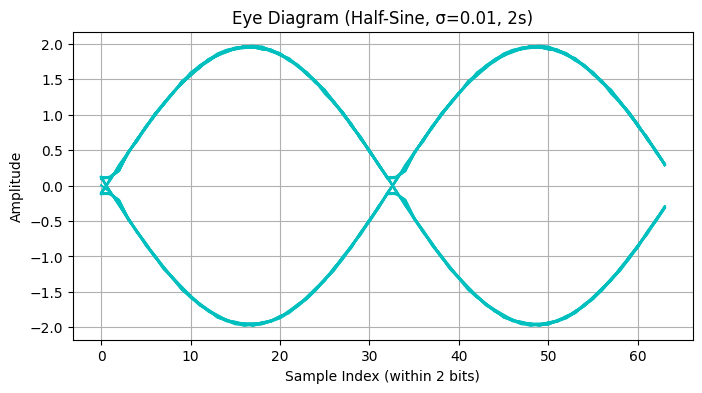

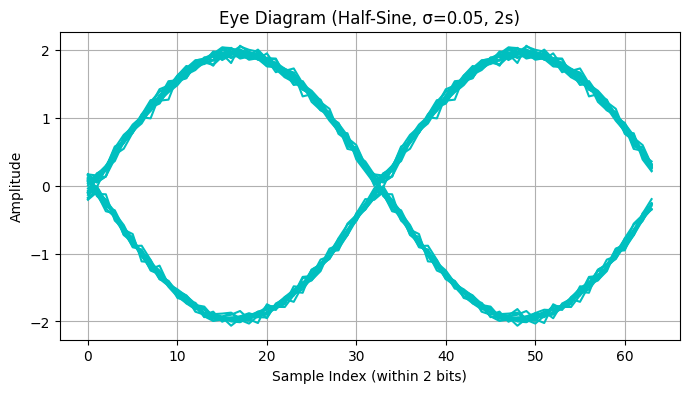

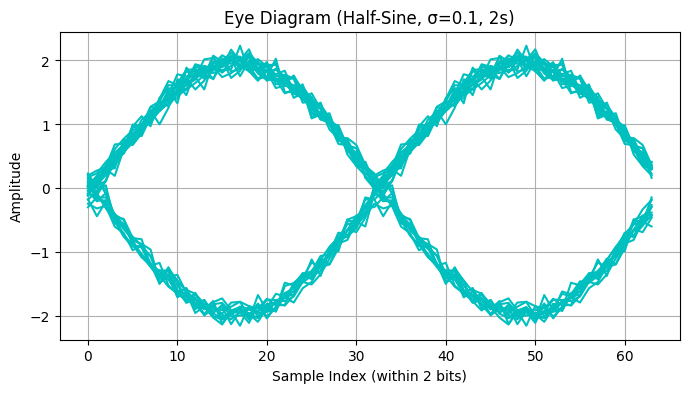

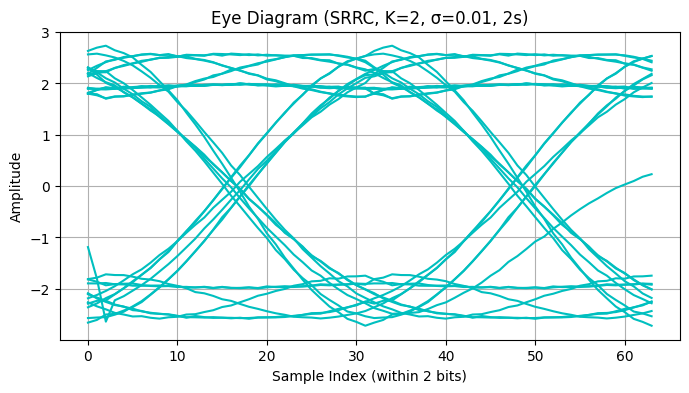

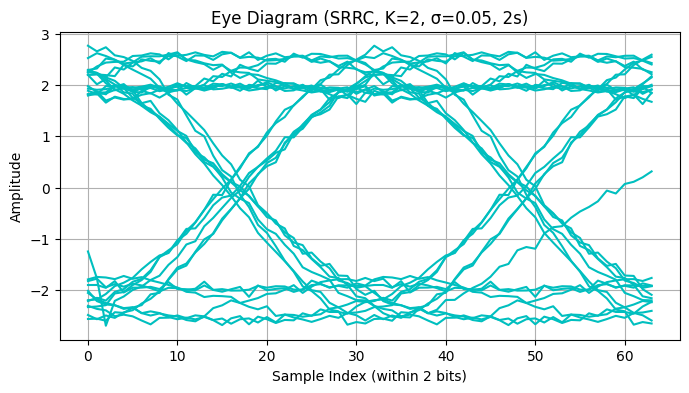

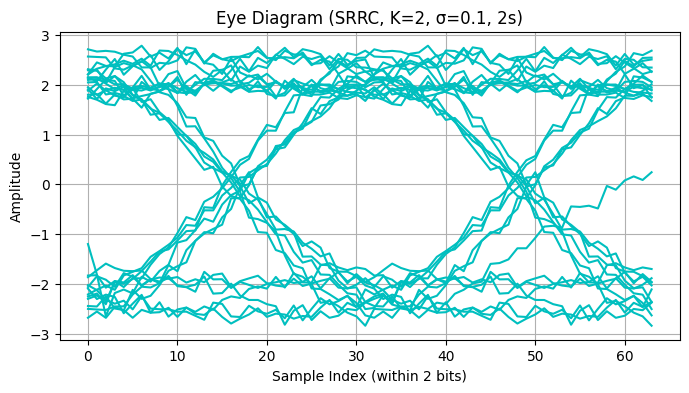

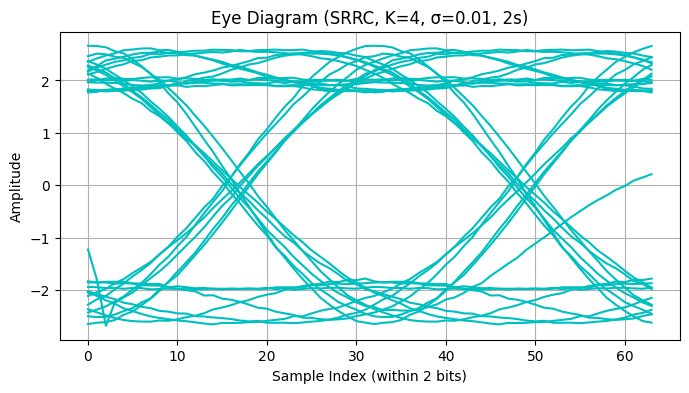

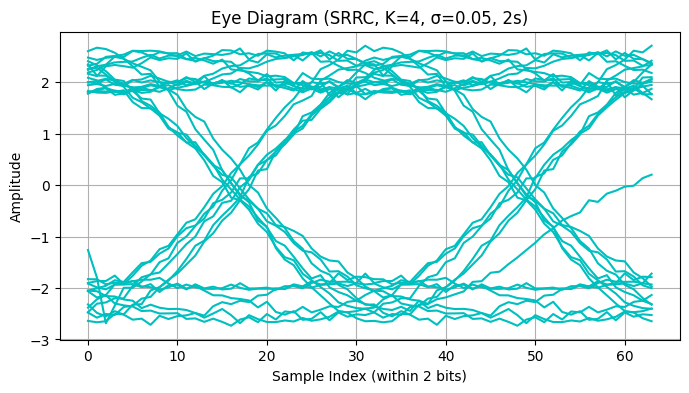

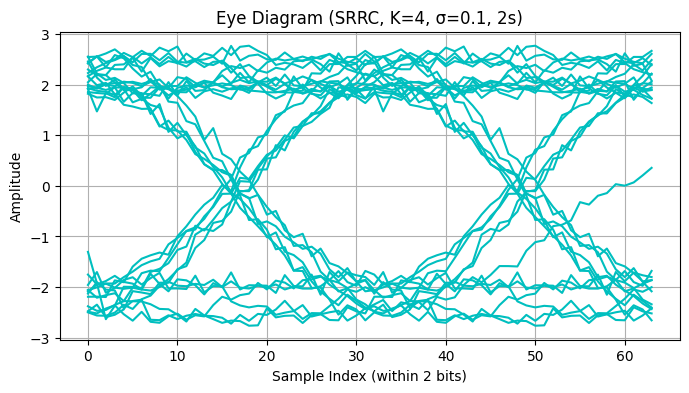

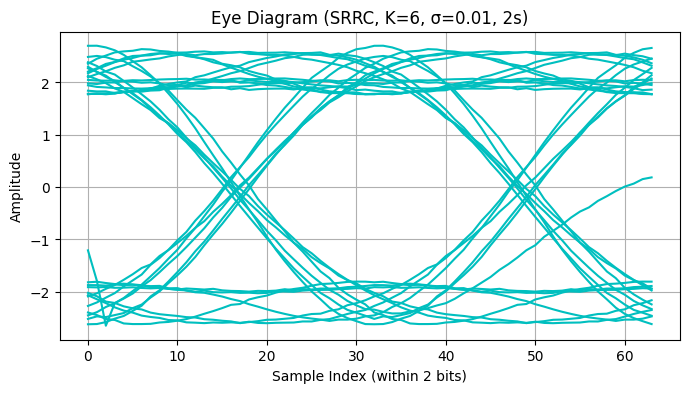

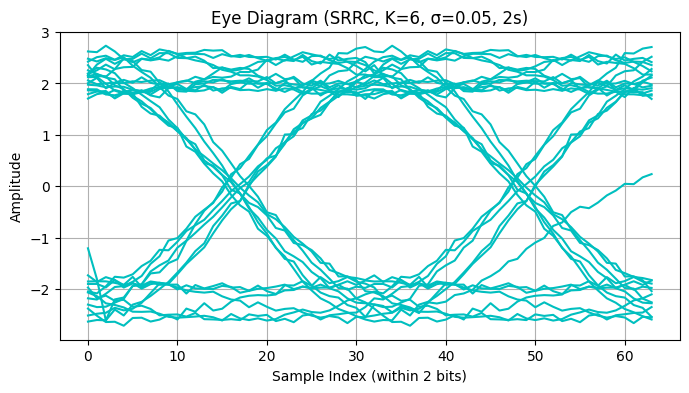

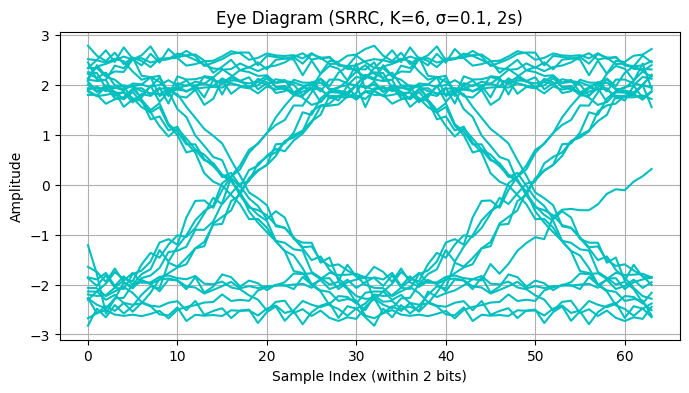

In [15]:
# Channel Impulse Response
def get_channel_impulse_response():
    return np.array([1.0, 1.0/2.0, 3.0/4.0, -2.0/7.0])

'''
def srrc_pulse_time_domain(t, T=1.0, beta=0.5, eps=1e-12):
    if abs(t) < eps:
        return 1.0 - beta + 4*beta/np.pi
    critical = T/(4*beta)
    if abs(abs(t) - critical) < eps:
        return (beta / np.sqrt(2)) * (
            (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
            (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
        )
    num = np.sin(np.pi*(1-beta)*t/T) + 4*beta*(t/T)*np.cos(np.pi*(1+beta)*t/T)
    den = np.pi*(t/T)*(1 - (4*beta*(t/T))**2)
    return num / (den + eps)

def half_sine_pulse_time_domain(t, T=1.0):
    if 0 <= t <= T:
        return np.sin(np.pi * t / T)
    return 0.0

def build_half_sine_transmit_signal(bits, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    for i, b in enumerate(bits):
        for idx, tj in enumerate(t_axis):
            tau = tj - i
            val = half_sine_pulse_time_domain(tau, T=1.0)
            x[idx] += b * val
    return t_axis, x

def build_srrc_transmit_signal(bits, K=2, beta=0.5, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N + 2*K
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    pulse_len = 2*K*sps
    t_pulse = np.linspace(-K, K, pulse_len, endpoint=False)
    p_srrc = np.array([srrc_pulse_time_domain(tp, T=1.0, beta=beta) for tp in t_pulse])
    
    for i, b in enumerate(bits):
        for idx_time, tj in enumerate(t_axis):
            tau = tj - i
            frac = (tau + K) / (2.0*K)
            idx_p = int(np.floor(frac * pulse_len))
            if 0 <= idx_p < pulse_len:
                x[idx_time] += b * p_srrc[idx_p]
    return t_axis, x
'''
# Eye Diagram (New version)
def plot_eye_diagram_one_second(signal, sps, num_bits, title="Eye Diagram"):
    
    plt.figure(figsize=(8,4))
    for i in range(num_bits):
        start = i*sps
        stop = start + sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, color='c')  # Ensure all lines are blue
    plt.title(title)
    plt.xlabel("Sample Index (within 1 bit)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_eye_diagram_two_seconds(signal, sps, num_bits, title="Eye Diagram (2-second)"):

    plt.figure(figsize=(8,4))
    for i in range(num_bits - 1):
        start = i*sps
        stop = start + 2*sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, color='c')  # Ensure all lines are blue
    plt.title(title)
    plt.xlabel("Sample Index (within 2 bits)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()
    
def main():
    np.random.seed(0)
    
    # 1) Generate random bits => polar +1/-1
    num_bits = 30
    bits_01 = np.random.randint(0, 2, size=num_bits)
    bits_polar = 2*bits_01 - 1
    
    # 2) Channel
    h = get_channel_impulse_response()  # length=4, spacing=1 sample
    
    # 3) Build Half-Sine -> channel -> noise
    sps = 32
    t_half, x_half = build_half_sine_transmit_signal(bits_polar, sps=sps)
    y_half = np.convolve(x_half, h, mode='full')
    
    # We'll test multiple noise levels:
    noise_stds = [0.01, 0.05, 0.1]
    
    # A) Show noisy results for Half-Sine
    for sigma in noise_stds:
        y_half_noisy = y_half + sigma * np.random.randn(len(y_half))
        
        # Eye diagrams
        #plot_eye_diagram_one_second(y_half_noisy, sps, num_bits,
        #    title=f"Eye Diagram (Half-Sine, σ={sigma}, 1s)")
        plot_eye_diagram_two_seconds(y_half_noisy, sps, num_bits,
            title=f"Eye Diagram (Half-Sine, σ={sigma}, 2s)")

    # B) SRRC with K=2,4,6 -> channel -> noise
    beta = 0.5
    for K in [2, 4, 6]:
        t_srrc, x_srrc = build_srrc_transmit_signal(bits_polar, K=K, beta=beta, sps=sps)
        y_srrc = np.convolve(x_srrc, h, mode='full')
        
        for sigma in noise_stds:
            y_srrc_noisy = y_srrc + sigma * np.random.randn(len(y_srrc))
            
            #plot_eye_diagram_one_second(y_srrc_noisy, sps, num_bits,
            #    title=f"Eye Diagram (SRRC, K={K}, σ={sigma}, 1s)")
            plot_eye_diagram_two_seconds(y_srrc_noisy, sps, num_bits,
                title=f"Eye Diagram (SRRC, K={K}, σ={sigma}, 2s)")

if __name__ == "__main__":
    main()



# Matched Filter in Time and Frequency Domain

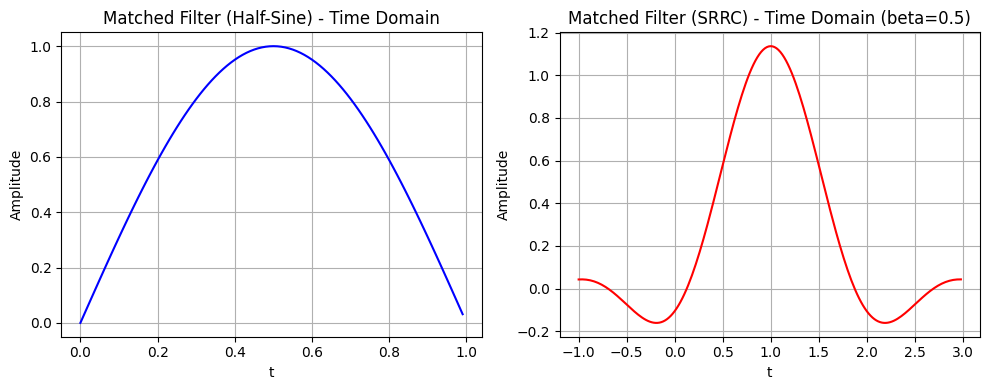

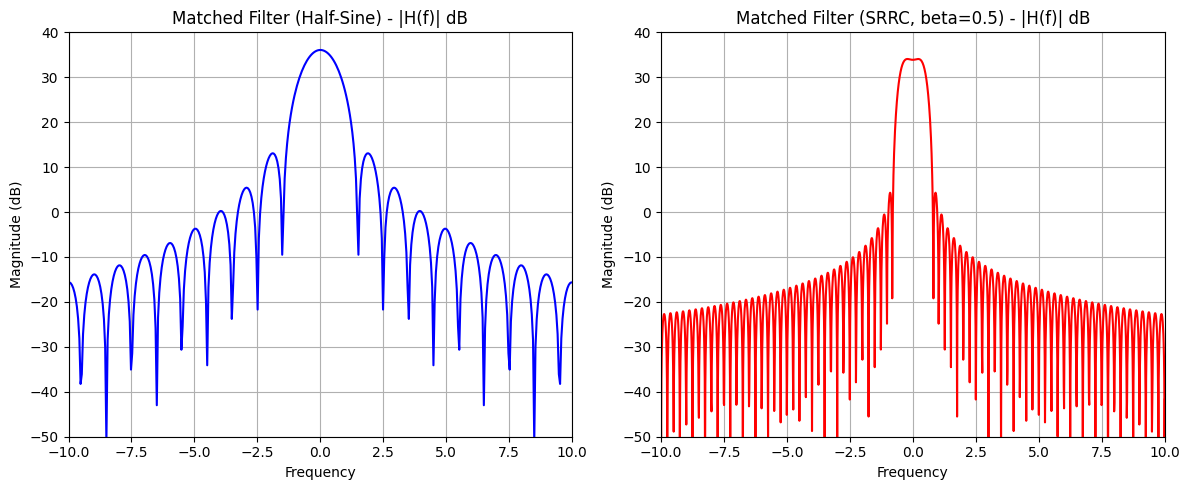

In [16]:
def half_sine_pulse(t, T):
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)

def srrc_matched_filter(t, beta=0.5, eps=1e-12):
    out = np.zeros_like(t, dtype=float)
    for i, ti in enumerate(t):
        a = 1.0 - ti  # convenience
        # Numerator / Denominator
        num = np.cos((np.pi*ti)/2.0) - 2.0*a*np.sin((3.0*np.pi*ti)/2.0)
        den = np.pi * a * (1.0 - 4.0*(a**2))

        # -- Case 1: near t=1 => a=0 
        if abs(a) < eps:
            out[i] = 1.0 - beta + (4.0*beta/np.pi)

        # -- Case 2: near 1 - 4(1 - t)^2=0 => that is 1 - 4 a^2=0 => a^2=1/4
        elif abs(1.0 - 4.0*(a**2)) < eps:
            out[i] = (beta/np.sqrt(2.0)) * (
                (1.0 + 2.0/np.pi)*np.sin(np.pi/(4.0*beta))
                + (1.0 - 2.0/np.pi)*np.cos(np.pi/(4.0*beta))
            )
        else:
            out[i] = num / (den + eps)
    return out

def main():
    # Matched Filter for Half-Sine
    T = 1.0
    N_samp_half = 100
    t_half = np.linspace(0, T, N_samp_half, endpoint=False)
    h_half = half_sine_pulse(T - t_half, T)  # MF = g_half(T - t)

    # Matched Filter for SRRC
    beta = 0.5
    K = 2.0
    N_samp_srrc = 200
    # Sample from [1-K, 1+K] so the shifted pulse is centered at t=1
    t_srrc = np.linspace(1.0 - K, 1.0 + K, N_samp_srrc, endpoint=False)
    h_srrc = srrc_matched_filter(t_srrc, beta=beta)

    # Plot time-domain
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(t_half, h_half, 'b')
    plt.title("Matched Filter (Half-Sine) - Time Domain")
    plt.xlabel("t")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(t_srrc, h_srrc, 'r')
    plt.title(f"Matched Filter (SRRC) - Time Domain (beta={beta})")
    plt.xlabel("t")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Optionally, compute frequency response for each
    Nfft_half = 2048
    H_half = np.fft.fftshift(np.fft.fft(h_half, Nfft_half))
    freq_half = np.fft.fftshift(np.fft.fftfreq(Nfft_half, d=(t_half[1]-t_half[0])))
    
    Nfft_srrc = 4096
    dt_srrc = (2*K)/N_samp_srrc
    H_srrc = np.fft.fftshift(np.fft.fft(h_srrc, Nfft_srrc))
    freq_srrc = np.fft.fftshift(np.fft.fftfreq(Nfft_srrc, d=dt_srrc))
    
    eps = 1e-12
    H_half_dB = 20*np.log10(np.abs(H_half) + eps)
    H_srrc_dB = 20*np.log10(np.abs(H_srrc) + eps)

    # Plot frequency responses in dB
    plt.figure(figsize=(12,5))
    # Half-sine MF
    plt.subplot(1,2,1)
    plt.plot(freq_half, H_half_dB, 'b')
    plt.title("Matched Filter (Half-Sine) - |H(f)| dB")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude (dB)")
    plt.xlim([-10, 10])
    plt.ylim([-50, 40])
    plt.grid(True)
    
    # SRRC MF
    plt.subplot(1,2,2)
    plt.plot(freq_srrc, H_srrc_dB, 'r')
    plt.title(f"Matched Filter (SRRC, beta={beta}) - |H(f)| dB")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude (dB)")
    plt.xlim([-10, 10])
    plt.ylim([-50, 40])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


# Applying Matched Filter

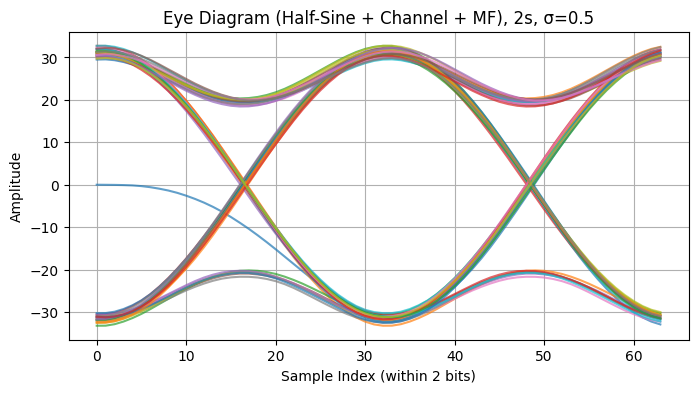

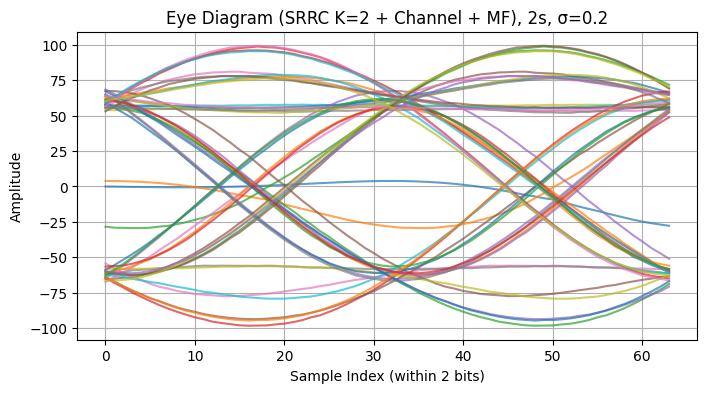

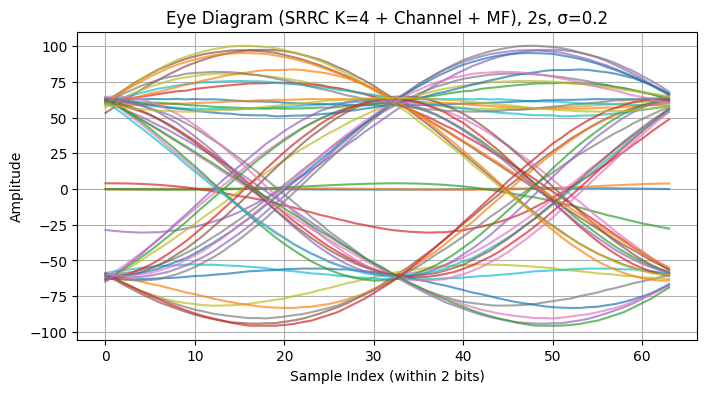

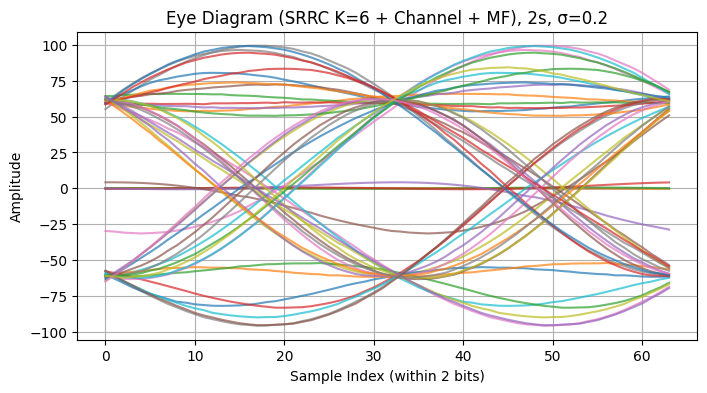

In [ ]:
def get_channel_impulse_response():
   return np.array([1.0, 0.5, 0.75, -2.0/7.0])

def half_sine_pulse_time_domain(t, T=1.0):
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)


def srrc_pulse_time_domain(t, T=1.0, beta=0.5, eps=1e-12):
    out = np.zeros_like(t)
    for i, ti in enumerate(t):
        tau = ti / T
        num = (np.sin(np.pi*(1-beta)*tau) +
               4*beta*tau*np.cos(np.pi*(1+beta)*tau))
        den = np.pi*tau * (1 - (4*beta*tau)**2)
        if abs(ti) < eps:
            # limit as t -> 0
            out[i] = 1 - beta + (4*beta/np.pi)
        elif abs(1 - 4*beta*tau) < eps or abs(1 + 4*beta*tau) < eps:
            # approximate limit near zero denominator
            out[i] = (beta/np.sqrt(2))*(
                (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
                (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
            )
        else:
            out[i] = num / (den + eps)
    return out

def build_half_sine_transmit_signal(bits, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    for i, b in enumerate(bits):
        for idx, tj in enumerate(t_axis):
            tau = tj - i
            val = half_sine_pulse_time_domain(tau, T=1.0)
            x[idx] += b * val
    return t_axis, x


def build_srrc_transmit_signal(bits, K=2, beta=0.5, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N + 2*K
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    pulse_len = 2*K*sps
    t_pulse = np.linspace(-K, K, pulse_len, endpoint=False)
    p_srrc = srrc_pulse_time_domain(t_pulse, 1.0, beta)
    
    for i, b in enumerate(bits):
        for idx_time, tj in enumerate(t_axis):
            tau = tj - i
            frac = (tau + K) / (2.0*K)
            idx_p = int(np.floor(frac * pulse_len))
            if 0 <= idx_p < pulse_len:
                x[idx_time] += b * p_srrc[idx_p]
    return t_axis, x

def matched_filter_half_sine(sps=32):
    t = np.linspace(0, 1, sps, endpoint=False)
    h_mf = half_sine_pulse_time_domain(1 - t, T=1.0)
    return h_mf


def srrc_matched_filter_time_domain(t, beta=0.5, eps=1e-12):
    out = np.zeros_like(t)
    for i, ti in enumerate(t):
        a = 1.0 - ti  # convenience: a=1 - t
        num = (np.cos(np.pi*ti/2.0)
               - 2.0*a*np.sin(3.0*np.pi*ti/2.0))
        den = np.pi*a*(1.0 - 4.0*(a**2))

        # near t=1 => a=0
        if abs(a) < eps:
            out[i] = 1.0 - beta + (4.0*beta/np.pi)

        # near the denominator=0 => 1 - 4 a^2=0 => a^2=1/4 => a=±1/2
        elif abs(1.0 - 4.0*(a**2)) < eps:
            # limit expression => (beta/sqrt(2)) * ...
            out[i] = (beta/np.sqrt(2.0)) * (
                (1.0 + 2.0/np.pi)*np.sin(np.pi/(4.0*beta)) +
                (1.0 - 2.0/np.pi)*np.cos(np.pi/(4.0*beta))
            )
        else:
            out[i] = num / (den + eps)
    return out


def matched_filter_srrc(K=2, beta=0.5, sps=32):
    # Discrete-time sample points from 1-K up to 1+K
    t = np.linspace(1.0 - K, 1.0 + K, 2*K*sps, endpoint=False)
    h_mf = srrc_matched_filter_time_domain(t, beta=beta)
    return h_mf

def plot_eye_diagram_one_second(signal, sps, num_bits, title="Eye Diagram"):
    plt.figure(figsize=(8,4))
    for i in range(num_bits):
        start = i*sps
        stop = start + sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.7)
    plt.title(title)
    plt.xlabel("Sample Index (within 1 bit)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_eye_diagram_two_seconds(signal, sps, num_bits, title="Eye Diagram (2s)"):
    plt.figure(figsize=(8,4))
    for i in range(num_bits - 1):
        start = i*sps
        stop = start + 2*sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.7)
    plt.title(title)
    plt.xlabel("Sample Index (within 2 bits)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def main():
    np.random.seed(0)
    # Generate random bits
    num_bits = 50
    bits_01 = np.random.randint(0, 2, size=num_bits)
    bits_polar = 2*bits_01 - 1
    
    sps = 32
    sigma = 0.2  

    t_half, x_half = build_half_sine_transmit_signal(bits_polar, sps=sps)
    
    # Pass through channel
    h = get_channel_impulse_response()
    y_half = np.convolve(x_half, h, mode='full')
    
    # Add AWGN
    y_half_noisy = y_half + sigma * np.random.randn(len(y_half))
    
    # Convolve with matched filter (half-sine)
    h_mf_half = matched_filter_half_sine(sps=sps)
    y_half_mf = np.convolve(y_half_noisy, h_mf_half, mode='full')
    
    # Eye diagrams
    #plot_eye_diagram_one_second(y_half_mf, sps, num_bits,
    #    title="Eye Diagram (Half-Sine + Channel + MF), 1s, σ=0.5")
    plot_eye_diagram_two_seconds(y_half_mf, sps, num_bits,
        title="Eye Diagram (Half-Sine + Channel + MF), 2s, σ=0.5")

    # SRRC
    K_vals = [2, 4, 6]
    beta = 0.3
    
    for K in K_vals:
        # Build TX
        t_srrc, x_srrc = build_srrc_transmit_signal(bits_polar, K=K, beta=beta, sps=sps)
        # Channel
        y_srrc = np.convolve(x_srrc, h, mode='full')
        # Noise
        y_srrc_noisy = y_srrc + sigma * np.random.randn(len(y_srrc))
        
        # Matched filter for SRRC 
        h_mf_srrc = matched_filter_srrc(K=K, beta=beta, sps=sps)
        y_srrc_mf = np.convolve(y_srrc_noisy, h_mf_srrc, mode='full')
        
        # Eye diagrams
        #plot_eye_diagram_one_second(y_srrc_mf, sps, num_bits,
        #    title=f"Eye Diagram (SRRC K={K} + Channel + MF), 1s, σ={sigma}")
        plot_eye_diagram_two_seconds(y_srrc_mf, sps, num_bits,
            title=f"Eye Diagram (SRRC K={K} + Channel + MF), 2s, σ={sigma}")

if __name__ == "__main__":
    main()


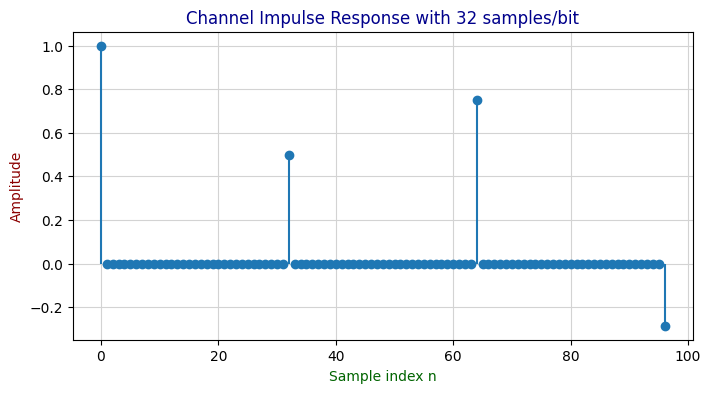

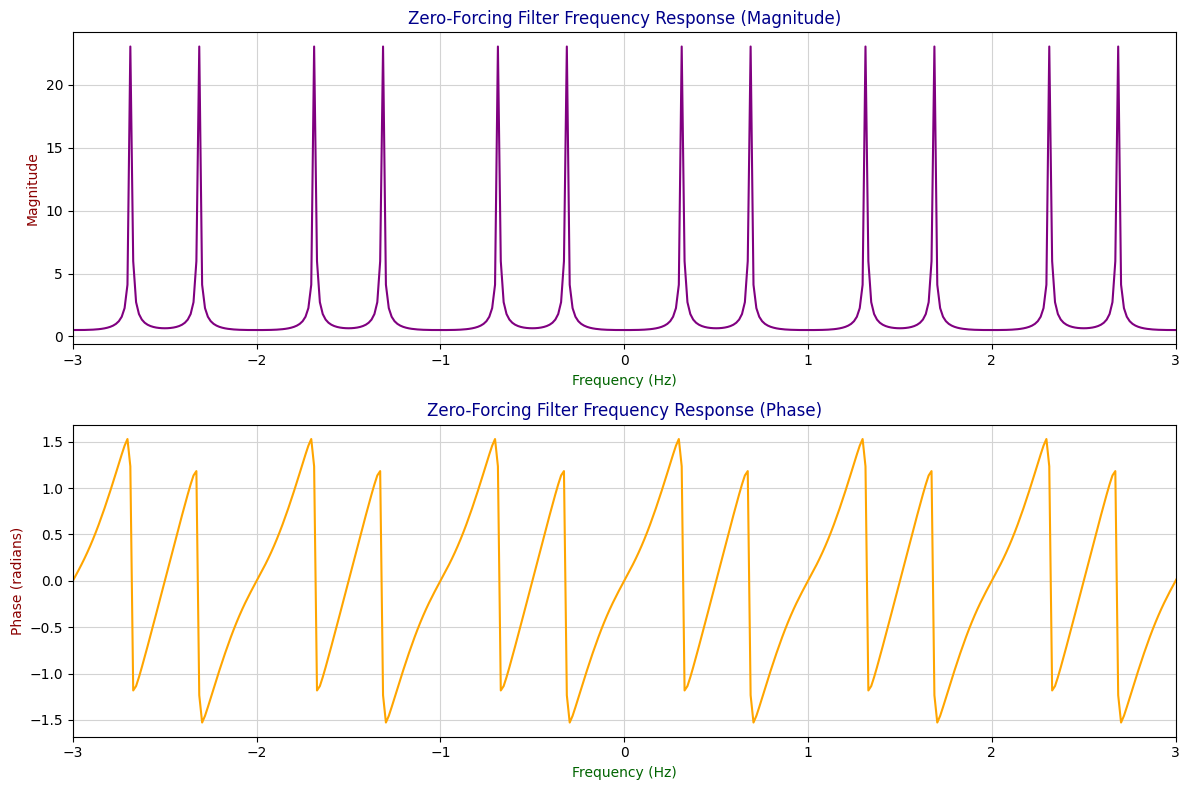

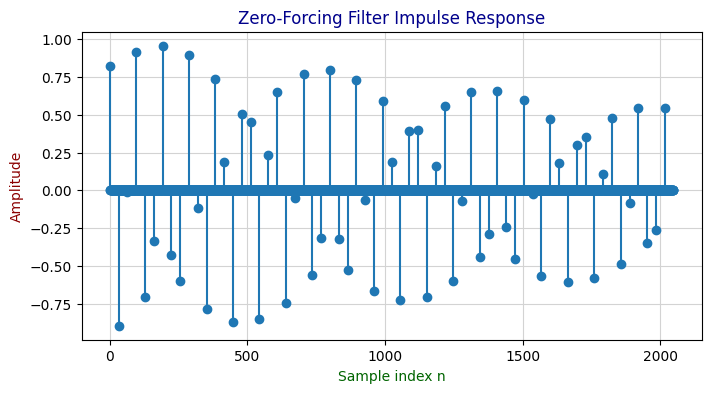

In [ ]:
from scipy.fft import fft, ifft, fftfreq
import scipy.fftpack

def main():
    sps = 32  
    tap0 = 1.0
    tap1 = 0.5
    tap2 = 0.75
    tap3 = -2/7
    
    # Build the impulse response in sample terms.
    h_len = 3 * sps + 1
    h = np.zeros(h_len)
    
    h[0]      = tap0
    h[sps]    = tap1
    h[2 * sps]  = tap2
    h[3 * sps]  = tap3

    # Plot impulse response 
    plt.figure(figsize=(8,4))
    plt.stem(np.arange(h_len), h, basefmt=" ")
    plt.title("Channel Impulse Response with 32 samples/bit", color='darkblue')
    plt.xlabel("Sample index n", color='darkgreen')
    plt.ylabel("Amplitude", color='darkred')
    plt.grid(True, color='lightgrey')
    plt.show()
    
    # Compute FFT of the impulse response
    H = fft(h, n=2048)  # Zero-padding to 2048 points for better frequency resolution
    frequencies = fftfreq(len(H), 1 / sps)  # Frequency axis
    
    # Shift the FFT result and frequencies to arrange positive and negative frequencies
    shifted_frequencies = scipy.fftpack.fftshift(frequencies)
    shifted_H = scipy.fftpack.fftshift(H)
    
    # Magnitude and Phase of the FFT
    H_mag = np.abs(shifted_H)
    H_phase = np.angle(shifted_H)
    
    # Zero-Forcing Filter Frequency Response 
    # Compute the inverse of the frequency response
    H_zf = 1 / shifted_H  # Inverse of the frequency response
    
    # --- Plot Frequency Response of ZF Filter ---
    plt.figure(figsize=(12, 8))
    
    # Magnitude Response of ZF Filter
    plt.subplot(2,1,1)
    plt.plot(shifted_frequencies, np.abs(H_zf), color='purple')
    plt.title("Zero-Forcing Filter Frequency Response (Magnitude)", color='darkblue')
    plt.xlabel("Frequency (Hz)", color='darkgreen')
    plt.xlim([-3, 3])
    plt.ylabel("Magnitude", color='darkred')
    plt.grid(True, color='lightgrey')
    
    # Phase Response of ZF Filter
    plt.subplot(2,1,2)
    plt.plot(shifted_frequencies, np.angle(H_zf), color='orange')
    plt.title("Zero-Forcing Filter Frequency Response (Phase)", color='darkblue')
    plt.xlabel("Frequency (Hz)", color='darkgreen')
    plt.xlim([-3, 3])
    plt.ylabel("Phase (radians)", color='darkred')
    plt.grid(True, color='lightgrey')
    
    plt.tight_layout()
    plt.show()
    
    # --- Inverse FFT to get the Impulse Response of ZF Filter ---
    h_zf = np.real(ifft(H_zf))  # Take real part to avoid imaginary noise
    
    # --- Plot Impulse Response of ZF Filter ---
    plt.figure(figsize=(8,4))
    plt.stem(np.arange(len(h_zf)), h_zf, basefmt=" ")
    plt.title("Zero-Forcing Filter Impulse Response", color='darkblue')
    plt.xlabel("Sample index n", color='darkgreen')
    plt.ylabel("Amplitude", color='darkred')
    plt.grid(True, color='lightgrey')
    plt.show()

if __name__ == "__main__":
    main()


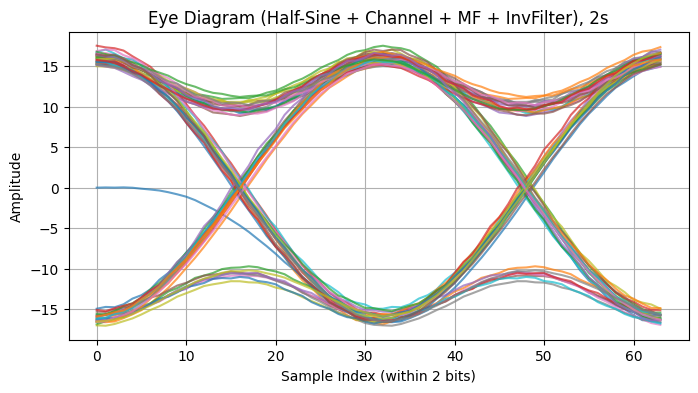

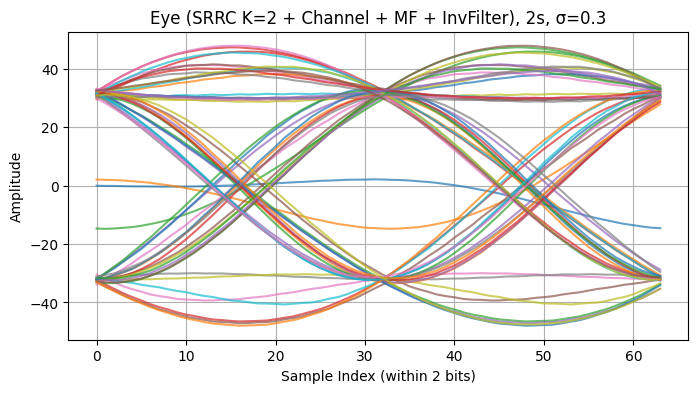

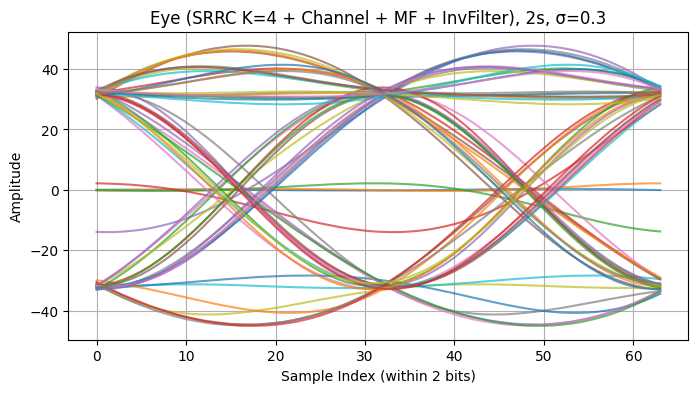

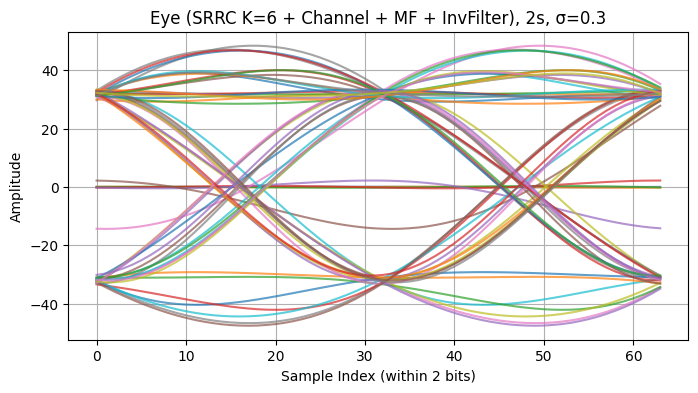

In [ ]:
# Channel Impulse Response
def get_channel_impulse_response():
    return np.array([1.0, 0.5, 0.75, -2.0/7.0])

# 2) Inverse Filter for the Channel
def get_channel_inverse_filter():
    b_inv = np.array([1.0])
    a_inv = np.array([1.0, 0.5, 0.75, -2.0/7.0])
    return b_inv, a_inv

def half_sine_pulse_time_domain(t, T=1.0):
    
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)

def srrc_pulse_time_domain(t, T=1.0, beta=0.5, eps=1e-12):
    out = np.zeros_like(t)
    for i, ti in enumerate(t):
        tau = ti / T
        num = (np.sin(np.pi*(1-beta)*tau) +
               4*beta*tau*np.cos(np.pi*(1+beta)*tau))
        den = np.pi*tau * (1 - (4*beta*tau)**2)
        if abs(ti) < eps:
            out[i] = 1 - beta + (4*beta/np.pi)
        elif abs(1 - 4*beta*tau) < eps or abs(1 + 4*beta*tau) < eps:
            out[i] = (beta/np.sqrt(2))*(
                (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
                (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
            )
        else:
            out[i] = num / (den + eps)
    return out


def build_half_sine_transmit_signal(bits, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    for i, b in enumerate(bits):
        for idx, tj in enumerate(t_axis):
            tau = tj - i
            val = half_sine_pulse_time_domain(tau, T=1.0)
            x[idx] += b * val
    return t_axis, x

def build_srrc_transmit_signal(bits, K=2, beta=0.5, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N + 2*K
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    pulse_len = 2*K*sps
    t_pulse = np.linspace(-K, K, pulse_len, endpoint=False)
    p_srrc = srrc_pulse_time_domain(t_pulse, 1.0, beta)
    
    for i, b in enumerate(bits):
        for idx_time, tj in enumerate(t_axis):
            tau = tj - i
            frac = (tau + K) / (2.0*K)
            idx_p = int(np.floor(frac * pulse_len))
            if 0 <= idx_p < pulse_len:
                x[idx_time] += b * p_srrc[idx_p]
    return t_axis, x

def matched_filter_half_sine(sps=32):
    t = np.linspace(0, 1, sps, endpoint=False)
    h_mf = half_sine_pulse_time_domain(1 - t, T=1.0)
    return h_mf

def srrc_matched_filter_time_domain(t, beta=0.5, eps=1e-12):
    out = np.zeros_like(t)
    # This is a placeholder or piecewise approach for demonstration.
    for i, ti in enumerate(t):
        # Some custom function, or just re-use srrc_pulse_time_domain(1-ti).
        pass
    # For demonstration, let's just call standard srrc at (1 - t):
    # But we'll do it carefully:
    out = srrc_pulse_time_domain(1.0 - t, T=1.0, beta=beta)
    return out

def matched_filter_srrc(K=2, beta=0.5, sps=32):
    t = np.linspace(1.0 - K, 1.0 + K, 2*K*sps, endpoint=False)
    h_mf = srrc_matched_filter_time_domain(t, beta=beta)
    return h_mf

def plot_eye_diagram_one_second(signal, sps, num_bits, title="Eye Diagram"):
    """
    Overlay intervals of length 'sps' (1 symbol).
    """
    plt.figure(figsize=(8,4))
    for i in range(num_bits):
        start = i*sps
        stop = start + sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.7)
    plt.title(title)
    plt.xlabel("Sample Index (within 1 bit)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_eye_diagram_two_seconds(signal, sps, num_bits, title="Eye Diagram (2s)"):
    """
    Overlay intervals of length '2*sps' (2 symbols).
    """
    plt.figure(figsize=(8,4))
    for i in range(num_bits - 1):
        start = i*sps
        stop = start + 2*sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.7)
    plt.title(title)
    plt.xlabel("Sample Index (within 2 bits)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def main():
    import scipy.signal as spsig
    
    np.random.seed(0)
    
    # Generate random bits 
    num_bits = 60
    bits_01 = np.random.randint(0, 2, size=num_bits)
    bits_polar = 2*bits_01 - 1
    
    sps = 32
    sigma = 0.3  
    
    # Get the channel & its inverse filter
    h = get_channel_impulse_response()
    b_inv, a_inv = get_channel_inverse_filter()
    
    # A) Half-Sine (MODIFIED ORDER)
    t_half, x_half = build_half_sine_transmit_signal(bits_polar, sps=sps)
    
    # Channel effects
    y_half = np.convolve(x_half, h, mode='full')
    y_half_noisy = y_half + sigma * np.random.randn(len(y_half))
    
    # NEW ORDER: Matched filter FIRST
    h_mf_half = matched_filter_half_sine(sps=sps)
    y_half_mf = np.convolve(y_half_noisy, h_mf_half, mode='full')
    
    # THEN inverse filter
    y_half_mf_inv = spsig.lfilter(b_inv, a_inv, y_half_mf)
    
    # Updated eye diagram
    plot_eye_diagram_two_seconds(
        y_half_mf_inv, sps, num_bits,
        title="Eye Diagram (Half-Sine + Channel + MF + InvFilter), 2s"
    )

    K_vals = [2, 4, 6]
    beta = 0.5
    
    for K in K_vals:
        # Transmit signal
        t_srrc, x_srrc = build_srrc_transmit_signal(bits_polar, K=K, beta=beta, sps=sps)
        
        # Channel effects
        y_srrc = np.convolve(x_srrc, h, mode='full')
        y_srrc_noisy = y_srrc + sigma * np.random.randn(len(y_srrc))
        
        # NEW ORDER: Matched filter FIRST
        h_mf_srrc = matched_filter_srrc(K=K, beta=beta, sps=sps)
        y_srrc_mf = np.convolve(y_srrc_noisy, h_mf_srrc, mode='full')
        
        # THEN inverse filter
        y_srrc_mf_inv = spsig.lfilter(b_inv, a_inv, y_srrc_mf)
        
        # Updated eye diagram
        plot_eye_diagram_two_seconds(
            y_srrc_mf_inv, sps, num_bits,
            title=f"Eye (SRRC K={K} + Channel + MF + InvFilter), 2s, σ={sigma}"
        )

if __name__ == "__main__":
    main()

# MMSE

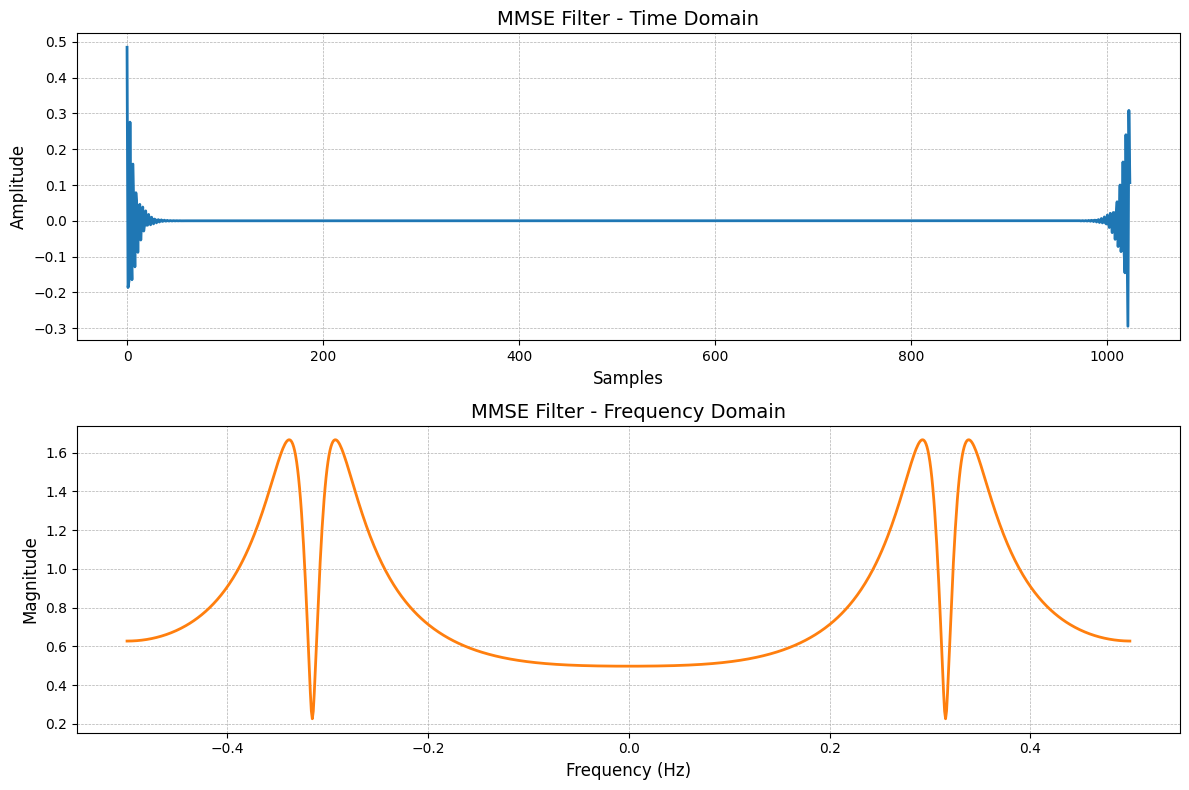

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftshift

# 1) Channel Impulse Response (as provided)
def get_channel_impulse_response():
    return np.array([1.0, 0.5, 0.75, -2.0/7.0])

# 2) Exact MMSE Equalizer (No Taylor Series Approximation)
def get_mmse_equalizer(H, sigma=1):
    """
    Design the MMSE equalizer using the exact formula.
    H: Frequency response of the channel.
    sigma: Noise standard deviation (variance of noise).
    """
    H_magnitude_squared = np.abs(H)**2
    H_conj = np.conj(H)
    
    Q_MMSE = H_conj / (H_magnitude_squared + sigma**2)
    
    return Q_MMSE

def plot_filter_time_frequency(mmse_filter, fs=1, title="MMSE Filter"):
    # Time Domain Plot
    plt.figure(figsize=(12, 8))
    
    # Time domain plot
    plt.subplot(2, 1, 1)
    plt.plot(np.arange(len(mmse_filter)), mmse_filter, color='tab:blue', linewidth=2)
    plt.title(f"{title} - Time Domain", fontsize=14)
    plt.xlabel("Samples", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    
    # Frequency Domain Plot
    plt.subplot(2, 1, 2)
    # Compute the frequency response
    freq_response = fft(mmse_filter)
    freq_axis = fftshift(np.fft.fftfreq(len(mmse_filter), d=1/fs))
    plt.plot(freq_axis, np.abs(fftshift(freq_response)), color='tab:orange', linewidth=2)
    plt.title(f"{title} - Frequency Domain", fontsize=14)
    plt.xlabel("Frequency (Hz)", fontsize=12)
    plt.ylabel("Magnitude", fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    
def main():
    # Get the channel impulse response
    h = get_channel_impulse_response()
    
    # Compute the frequency response of the channel (FFT of h)
    H = fft(h, 1024)  # Using 1024 points for frequency resolution
    
    # Design the MMSE equalizer using the exact formula
    sigma = 0.3  # Noise standard deviation (can vary)
    Q_MMSE = get_mmse_equalizer(H, sigma=sigma)
    
    # Convert MMSE filter back to time domain (Inverse FFT)
    mmse_filter_time_domain = np.real(ifft(Q_MMSE))
    
    # Plot the MMSE filter in both time and frequency domains
    plot_filter_time_frequency(mmse_filter_time_domain, fs=1.0)

if __name__ == "__main__":
    main()



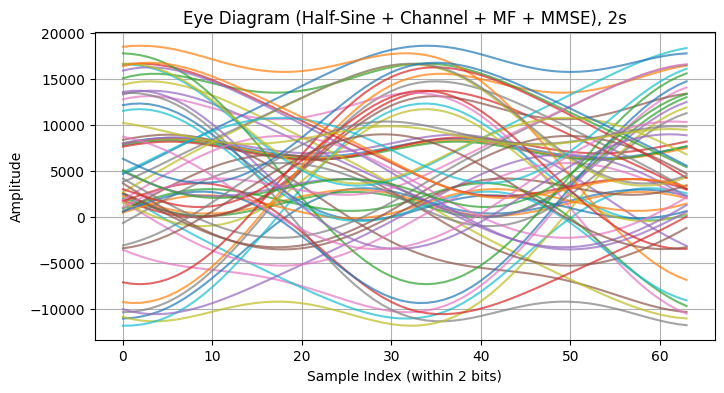

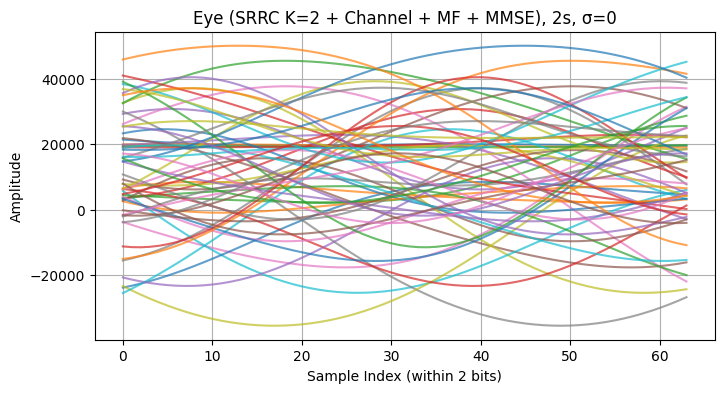

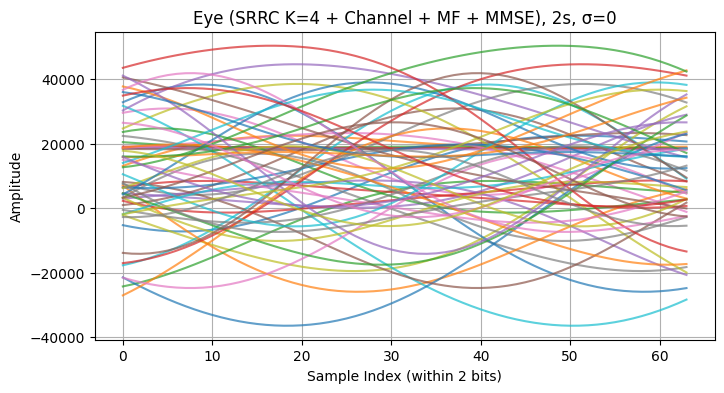

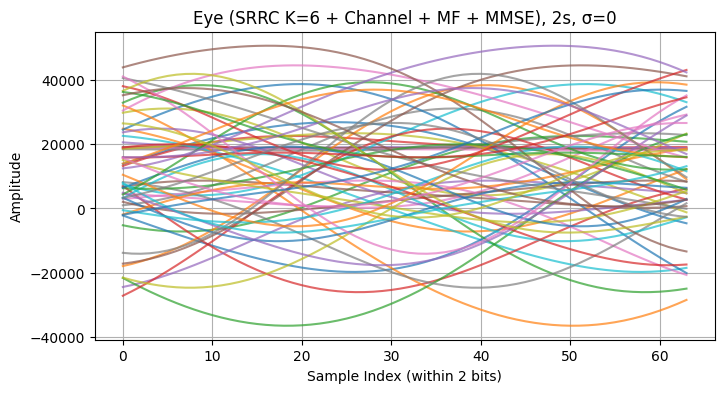

In [ ]:
import scipy.signal as spsig

def get_channel_impulse_response():
    return np.array([1.0, 0.5, 0.75, -2.0/7.0])

def get_mmse_equalizer(H, sigma=1):
    
    H_magnitude = np.abs(H)
    
    # For sigma = 0, revert to the inverse filter (no noise case)
    if sigma == 0:
        Q_MMSE = np.conj(H) / (H_magnitude**2)  # Inverse filter behavior (1/H)
    else:
        # Taylor series approximation for small sigma
        correction_term = 1 - 2 * (sigma / H_magnitude)**2
        Q_MMSE = np.conj(H) / (H_magnitude**2) * correction_term
    
    return Q_MMSE

def half_sine_pulse_time_domain(t, T=1.0):
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)

def srrc_pulse_time_domain(t, T=1.0, beta=0.5, eps=1e-12):
    out = np.zeros_like(t)
    for i, ti in enumerate(t):
        tau = ti / T
        num = (np.sin(np.pi*(1-beta)*tau) +
               4*beta*tau*np.cos(np.pi*(1+beta)*tau))
        den = np.pi*tau * (1 - (4*beta*tau)**2)
        if abs(ti) < eps:
            out[i] = 1 - beta + (4*beta/np.pi)
        elif abs(1 - 4*beta*tau) < eps or abs(1 + 4*beta*tau) < eps:
            out[i] = (beta/np.sqrt(2))*(
                (1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
                (1 - 2/np.pi)*np.cos(np.pi/(4*beta))
            )
        else:
            out[i] = num / (den + eps)
    return out

def matched_filter_half_sine(sps=32):
    t = np.linspace(0, 1, sps, endpoint=False)
    h_mf = half_sine_pulse_time_domain(1 - t, T=1.0)
    return h_mf

def matched_filter_srrc(K=2, beta=0.5, sps=32):
    t = np.linspace(1.0 - K, 1.0 + K, 2*K*sps, endpoint=False)
    h_mf = srrc_pulse_time_domain(t, T=1.0, beta=beta)
    return h_mf

def plot_eye_diagram_two_seconds(signal, sps, num_bits, title="Eye Diagram (2s)"):
    plt.figure(figsize=(8,4))
    for i in range(num_bits - 1):
        start = i*sps
        stop = start + 2*sps
        if stop > len(signal):
            break
        seg = signal[start:stop]
        plt.plot(np.arange(len(seg)), seg, alpha=0.7)
    plt.title(title)
    plt.xlabel("Sample Index (within 2 bits)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


def main():
    np.random.seed(0)
    # Generate random bits => polar +1/-1
    num_bits = 60
    bits_01 = np.random.randint(0, 2, size=num_bits)
    bits_polar = 2*bits_01 - 1
    
    sps = 32
    sigma = 0  # noise std
    
    # Get the channel impulse response and its frequency response
    h = get_channel_impulse_response()
    H = np.fft.fft(h, n=1024)  # FFT of the channel impulse response
    
    # Design the MMSE equalizer
    Q_MMSE = get_mmse_equalizer(H, sigma=sigma)

    t_half, x_half = build_half_sine_transmit_signal(bits_polar, sps=sps)
    
    # Channel effects
    y_half = np.convolve(x_half, h, mode='full')
    y_half_noisy = y_half + sigma * np.random.randn(len(y_half))
    
    # Matched filter
    h_mf_half = matched_filter_half_sine(sps=sps)
    y_half_mf = np.convolve(y_half_noisy, h_mf_half, mode='full')
    
    # Apply the MMSE equalizer
    y_half_mf_mmse = np.convolve(y_half_mf, Q_MMSE, mode='same')
    
    # Updated eye diagram
    plot_eye_diagram_two_seconds(
        y_half_mf_mmse, sps, num_bits,
        title="Eye Diagram (Half-Sine + Channel + MF + MMSE), 2s"
    )

    K_vals = [2, 4, 6]
    beta = 0.5
    
    for K in K_vals:
        # Transmit signal
        t_srrc, x_srrc = build_srrc_transmit_signal(bits_polar, K=K, beta=beta, sps=sps)
        
        # Channel effects
        y_srrc = np.convolve(x_srrc, h, mode='full')
        y_srrc_noisy = y_srrc + sigma * np.random.randn(len(y_srrc))
        
        # Matched filter
        h_mf_srrc = matched_filter_srrc(K=K, beta=beta, sps=sps)
        y_srrc_mf = np.convolve(y_srrc_noisy, h_mf_srrc, mode='full')
        
        # Apply the MMSE equalizer
        y_srrc_mf_mmse = np.convolve(y_srrc_mf, Q_MMSE, mode='same')
        
        # Updated eye diagram
        plot_eye_diagram_two_seconds(
            y_srrc_mf_mmse, sps, num_bits,
            title=f"Eye (SRRC K={K} + Channel + MF + MMSE), 2s, σ={sigma}"
        )

if __name__ == "__main__":
    main()


Original vector length: 1849600
Total bits to transmit: 14796800
Half-Sine BER: 0.6193264759948097
SRRC BER: 0.5028640652032872


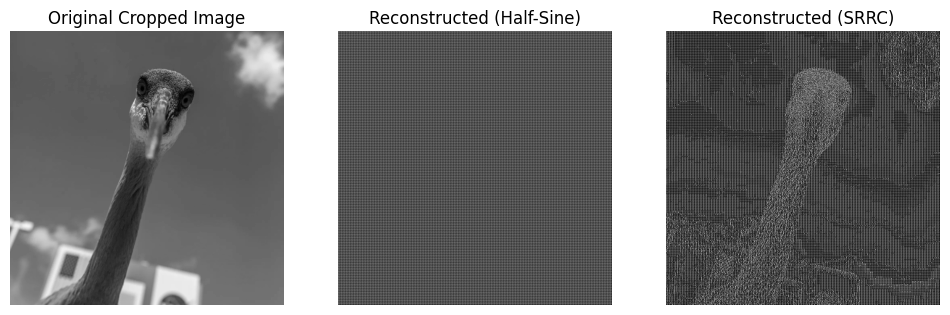

In [ ]:
import cv2
import scipy.signal as spsig
from scipy.fftpack import dct, idct
from skimage.util import view_as_blocks

# Converting Image to a Vector and Back


def image_to_vector(image):
    image = image.astype(np.float64)
    height, width = image.shape
    height_cropped = height - (height % 8)
    width_cropped  = width - (width % 8)
    image_cropped = image[:height_cropped, :width_cropped]
    
    # Break image into non-overlapping 8x8 blocks.
    blocks = view_as_blocks(image_cropped, block_shape=(8, 8))
    num_rows, num_cols, _, _ = blocks.shape
    
    dct_blocks = np.zeros_like(blocks, dtype=np.float64)
    for i in range(num_rows):
        for j in range(num_cols):
            dct_blocks[i, j] = dct(dct(blocks[i, j].T, norm='ortho').T, norm='ortho')
    
    # Scale all DCT coefficients to the range [0, 255].
    min_val = dct_blocks.min()
    max_val = dct_blocks.max()
    scaled_blocks = (dct_blocks - min_val) / (max_val - min_val) * 255.0
    quantized_blocks = np.round(scaled_blocks).astype(np.uint8)
    
    # Flatten the blocks into a 1D vector.
    blocks_flat = quantized_blocks.reshape(-1, 8, 8)
    vector = blocks_flat.reshape(-1)
    return vector, (min_val, max_val), image_cropped.shape

def vector_to_image(vector, scaling_params, image_shape):
    min_val, max_val = scaling_params
    height, width = image_shape
    n_blocks = (height // 8) * (width // 8)
    if vector.size != n_blocks * 64:
        raise ValueError("Vector length does not match image dimensions.")
    blocks_flat = vector.reshape(n_blocks, 8, 8)
    num_rows = height // 8
    num_cols = width // 8
    blocks = blocks_flat.reshape(num_rows, num_cols, 8, 8)
    
    # Undo scaling to recover approximate DCT coefficients.
    dct_blocks = blocks.astype(np.float64)
    dct_blocks = dct_blocks / 255.0 * (max_val - min_val) + min_val
    
    # Apply inverse 2D DCT on each block.
    rec_blocks = np.zeros_like(dct_blocks)
    for i in range(num_rows):
        for j in range(num_cols):
            rec_blocks[i, j] = idct(idct(dct_blocks[i, j].T, norm='ortho').T, norm='ortho')
    
    # Stitch blocks together.
    rows = [np.hstack(rec_blocks[i, :]) for i in range(num_rows)]
    rec_image = np.vstack(rows)
    rec_image = np.clip(np.round(rec_image), 0, 255).astype(np.uint8)
    return rec_image

def get_channel_impulse_response():
    return np.array([1.0, 0.5, 0.75, -2.0/7.0])

def get_channel_inverse_filter():
    b_inv = np.array([1.0])
    a_inv = np.array([1.0, 0.5, 0.75, -2.0/7.0])
    return b_inv, a_inv


def half_sine_pulse_time_domain(t, T=1.0):
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)

def srrc_pulse_time_domain(t, T=1.0, beta=0.5, eps=1e-12):
    out = np.zeros_like(t)
    for i, ti in enumerate(t):
        tau = ti / T
        num = (np.sin(np.pi * (1-beta) * tau) +
               4 * beta * tau * np.cos(np.pi * (1+beta) * tau))
        den = np.pi * tau * (1 - (4 * beta * tau) ** 2)
        if abs(ti) < eps:
            out[i] = 1 - beta + (4 * beta / np.pi)
        elif abs(1 - 4 * beta * tau) < eps or abs(1 + 4 * beta * tau) < eps:
            out[i] = (beta/np.sqrt(2)) * ((1 + 2/np.pi)*np.sin(np.pi/(4*beta)) +
                                          (1 - 2/np.pi)*np.cos(np.pi/(4*beta)))
        else:
            out[i] = num / (den + eps)
    return out

# ---- Transmit Signal Builders (Vectorized) ----
def build_half_sine_transmit_signal(bits, sps=32):
    num_bits = len(bits)
    # Upsample: create an array with zeros and insert the bits.
    upsamp = np.zeros(num_bits * sps)
    upsamp[::sps] = bits
    # Create a half-sine pulse sampled over one symbol period.
    t = np.linspace(0, 1, sps, endpoint=False)
    pulse = half_sine_pulse_time_domain(t, T=1.0)
    # Convolve upsampled bit stream with pulse.
    x = np.convolve(upsamp, pulse, mode='full')
    t_axis = np.arange(len(x)) / sps
    return t_axis, x

def build_srrc_transmit_signal(bits, K=2, beta=0.5, sps=32):
    """
    Vectorized transmit signal construction using an SRRC pulse.
    Upsample the bits and then convolve with an SRRC pulse that spans 2*K seconds.
    """
    num_bits = len(bits)
    upsamp = np.zeros(num_bits * sps)
    upsamp[::sps] = bits
    pulse_len = 2 * K * sps
    t_pulse = np.linspace(-K, K, pulse_len, endpoint=False)
    pulse = srrc_pulse_time_domain(t_pulse, T=1.0, beta=beta)
    x = np.convolve(upsamp, pulse, mode='full')
    t_axis = np.arange(len(x)) / sps
    return t_axis, x

# ---- Matched Filters ----
def matched_filter_half_sine(sps=32):
    t = np.linspace(0, 1, sps, endpoint=False)
    h_mf = half_sine_pulse_time_domain(1 - t, T=1.0)
    return h_mf

def matched_filter_srrc(K=2, beta=0.5, sps=32):
    t = np.linspace(1.0 - K, 1.0 + K, 2*K*sps, endpoint=False)
    h_mf = srrc_pulse_time_domain(1.0 - t, T=1.0, beta=beta)
    return h_mf

# ---- Receiver: Sampling and Decision Device ----
def sample_and_detect(received_signal, sps, num_symbols, delay):
    sampled = received_signal[delay : delay + num_symbols * sps : sps]
    detected = np.where(sampled > 0, 1, 0)
    return detected

def main():
    np.random.seed(0)
    
    # -------------------------
    # (a) Image-to-Vector
    # -------------------------
    image = cv2.imread('picture.jpg', cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise IOError("Could not load 'picture.jpg'.")
    
    vector, scaling_params, img_shape = image_to_vector(image)
    print("Original vector length:", vector.size)
    
    # Convert the vector (uint8) to a bitstream (each byte becomes 8 bits).
    tx_bits = np.unpackbits(vector)  # Array of 0s and 1s.
    num_bits = tx_bits.size
    print("Total bits to transmit:", num_bits)
    
    tx_polar = 2 * tx_bits - 1  
    
    sps = 32     
    sigma = 0.01   
    
    # Get channel impulse response and inverse filter.
    h = get_channel_impulse_response()
    b_inv, a_inv = get_channel_inverse_filter()
    
    t_tx, x_tx = build_half_sine_transmit_signal(tx_polar, sps=sps)
    
    # Channel: Convolve with channel impulse response.
    y_channel = np.convolve(x_tx, h, mode='full')
    # Add AWGN.
    y_noisy = y_channel + sigma * np.random.randn(len(y_channel))
    # Apply inverse filter.
    y_inv = spsig.lfilter(b_inv, a_inv, y_noisy)
    # Matched filtering.
    h_mf = matched_filter_half_sine(sps=sps)
    y_mf = np.convolve(y_inv, h_mf, mode='full')
    # Sample and detect.
    delay = sps // 2  # Adjust delay if needed.
    detected_bits_half = sample_and_detect(y_mf, sps, num_bits, delay)
    
    errors_half = np.sum(detected_bits_half != tx_bits)
    ber_half = errors_half / num_bits
    print("Half-Sine BER:", ber_half)
    
    # Reconstruct the transmitted vector from detected bits.
    rx_vector_half = np.packbits(detected_bits_half)
    rx_vector_half = rx_vector_half[:vector.size]
    rec_image_half = vector_to_image(rx_vector_half, scaling_params, img_shape)
    
    t_tx_srrc, x_tx_srrc = build_srrc_transmit_signal(tx_polar, K=2, beta=0.5, sps=sps)
    y_channel_srrc = np.convolve(x_tx_srrc, h, mode='full')
    y_noisy_srrc = y_channel_srrc + sigma * np.random.randn(len(y_channel_srrc))
    y_inv_srrc = spsig.lfilter(b_inv, a_inv, y_noisy_srrc)
    h_mf_srrc = matched_filter_srrc(K=2, beta=0.5, sps=sps)
    y_mf_srrc = np.convolve(y_inv_srrc, h_mf_srrc, mode='full')
    detected_bits_srrc = sample_and_detect(y_mf_srrc, sps, num_bits, delay)
    
    errors_srrc = np.sum(detected_bits_srrc != tx_bits)
    ber_srrc = errors_srrc / num_bits
    print("SRRC BER:", ber_srrc)
    
    rx_vector_srrc = np.packbits(detected_bits_srrc)
    rx_vector_srrc = rx_vector_srrc[:vector.size]
    rec_image_srrc = vector_to_image(rx_vector_srrc, scaling_params, img_shape)
    
    # Display Results
    cropped_image = image[:img_shape[0], :img_shape[1]]
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.title("Original Cropped Image")
    plt.imshow(cropped_image, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.title("Reconstructed (Half-Sine)")
    plt.imshow(rec_image_half, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.title("Reconstructed (SRRC)")
    plt.imshow(rec_image_srrc, cmap='gray')
    plt.axis('off')
    
    plt.show()

if __name__ == "__main__":
    main()


Vector length: 1849600


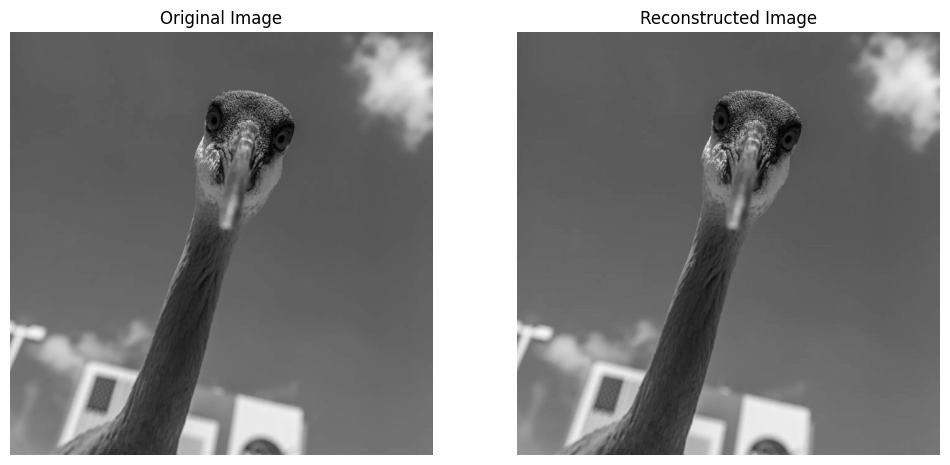

In [3]:
import cv2
def image_to_vector(image):
    # Convert to float for processing.
    image = image.astype(np.float64)
    height, width = image.shape
    
    # Crop the image so dimensions are divisible by 8.
    height_cropped = height - (height % 8)
    width_cropped  = width  - (width % 8)
    image_cropped = image[:height_cropped, :width_cropped]
    
    # Divide the image into non-overlapping 8x8 blocks.
    # blocks shape will be (num_rows, num_cols, 8, 8)
    blocks = view_as_blocks(image_cropped, block_shape=(8, 8))
    num_rows, num_cols, _, _ = blocks.shape

    # Allocate an array to hold the DCT coefficients.
    dct_blocks = np.zeros_like(blocks, dtype=np.float64)
    for i in range(num_rows):
        for j in range(num_cols):
            # Apply 2D DCT using two 1D DCTs.
            dct_blocks[i, j] = dct(dct(blocks[i, j].T, norm='ortho').T, norm='ortho')
    
    # Find global minimum and maximum of DCT coefficients.
    min_val = dct_blocks.min()
    max_val = dct_blocks.max()
    
    # Scale the DCT coefficients to the range [0, 255].
    scaled_blocks = (dct_blocks - min_val) / (max_val - min_val) * 255.0
    
    # Quantize by rounding and converting to uint8.
    quantized_blocks = np.round(scaled_blocks).astype(np.uint8)
    
    # Flatten the 8x8 blocks into one long vector.
    # First reshape into (number_of_blocks, 8, 8)
    blocks_flat = quantized_blocks.reshape(-1, 8, 8)
    # Then flatten each block and concatenate into a 1D vector.
    vector = blocks_flat.reshape(-1)
    
    return vector, (min_val, max_val), image_cropped.shape

def vector_to_image(vector, scaling_params, image_shape):
    
    min_val, max_val = scaling_params
    height, width = image_shape
    
    # Determine how many 8x8 blocks were used.
    n_blocks = (height // 8) * (width // 8)
    
    # Check that the vector length matches.
    if vector.size != n_blocks * 64:
        raise ValueError("Vector length does not match image dimensions.")
    
    # Reshape the vector into blocks of shape (n_blocks, 8, 8).
    blocks_flat = vector.reshape(n_blocks, 8, 8)
    
    # Reshape into grid form: (num_rows, num_cols, 8, 8)
    num_rows = height // 8
    num_cols = width // 8
    blocks = blocks_flat.reshape(num_rows, num_cols, 8, 8)
    
    # Undo the scaling: convert from [0, 255] back to the DCT coefficient range.
    # (Quantization is irreversible, but we can recover an approximation.)
    blocks = blocks.astype(np.float64)
    dct_blocks = blocks / 255.0 * (max_val - min_val) + min_val
    
    # Apply the inverse DCT on each block.
    rec_blocks = np.zeros_like(dct_blocks)
    for i in range(num_rows):
        for j in range(num_cols):
            rec_blocks[i, j] = idct(idct(dct_blocks[i, j].T, norm='ortho').T, norm='ortho')
    
    # Stitch the blocks back into the full image.
    rows = []
    for i in range(num_rows):
        row = np.hstack(rec_blocks[i, :])
        rows.append(row)
    rec_image = np.vstack(rows)
    
    # Clip to valid 8-bit range and convert to uint8.
    rec_image = np.clip(np.round(rec_image), 0, 255).astype(np.uint8)
    return rec_image


if __name__ == '__main__':
    # Load the image in grayscale.
    image = cv2.imread('picture.jpg', cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise IOError("Could not load 'picture.jpg'. Make sure the file exists in the working directory.")
    
    # Forward process: convert image to vector.
    vector, scaling_params, cropped_shape = image_to_vector(image)
    print("Vector length:", vector.size)
    
    # Inverse process: reconstruct image from vector.
    reconstructed_image = vector_to_image(vector, scaling_params, cropped_shape)
    
    # Show the original (cropped) image and the reconstructed image.
    # Note: the original image is cropped to multiples of 8.
    cropped_image = image[:cropped_shape[0], :cropped_shape[1]]
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(cropped_image, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Reconstructed Image")
    plt.imshow(reconstructed_image, cmap='gray')
    plt.axis('off')
    
    plt.show()


MSSE nEw

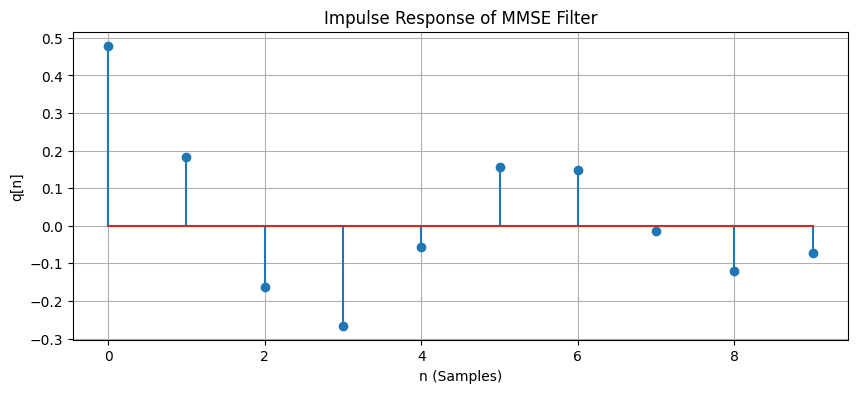

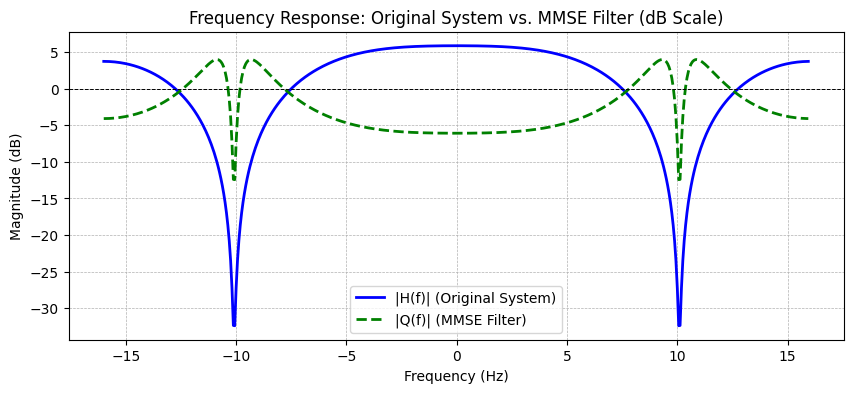

In [30]:
import numpy as np
import matplotlib.pyplot as plt

h_n = np.array([1, 1/2, 3/4, -2/7])  # Channel impulse response
fs = 32  # Sampling frequency

N = 512  # Number of frequency points
H_f = np.fft.fft(h_n, N)  # Compute the FFT of h[n]
frequencies_Hz = np.fft.fftfreq(N, d=1/fs)  # Compute frequencies in Hz

# Shift FFT output to ensure correct frequency order (negative to positive)
H_f = np.fft.fftshift(H_f)
frequencies_Hz = np.fft.fftshift(frequencies_Hz)

# MMSE Filter parameters
sigma_squared = 0.1  # Noise power, you can adjust this value

# Compute the magnitude squared of H(f)
H_f_mag_squared = np.abs(H_f) ** 2

# Compute the MMSE filter in the frequency domain
Q_f = (1 / H_f) * (H_f_mag_squared / (H_f_mag_squared + sigma_squared))

# Convert to dB scale for plotting
H_f_dB = 20 * np.log10(np.abs(H_f))
Q_f_dB = 20 * np.log10(np.abs(Q_f))

# Plot the impulse response of the MMSE filter (first 10 samples)
q_n = np.fft.ifft(Q_f, N)  # Compute the inverse FFT to get the time domain impulse response
plt.figure(figsize=(10, 4))
plt.stem(np.real(q_n[:10]))  # Plot the real part of the impulse response
plt.title("Impulse Response of MMSE Filter")
plt.xlabel("n (Samples)")
plt.ylabel("q[n]")
plt.grid()
plt.show()

# Plot frequency response of the original system and MMSE filter
plt.figure(figsize=(10, 4))
plt.plot(frequencies_Hz, H_f_dB, label="|H(f)| (Original System)", color='blue', linewidth=2)
plt.plot(frequencies_Hz, Q_f_dB, label="|Q(f)| (MMSE Filter)", color='green', linestyle='dashed', linewidth=2)
plt.title("Frequency Response: Original System vs. MMSE Filter (dB Scale)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.7)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


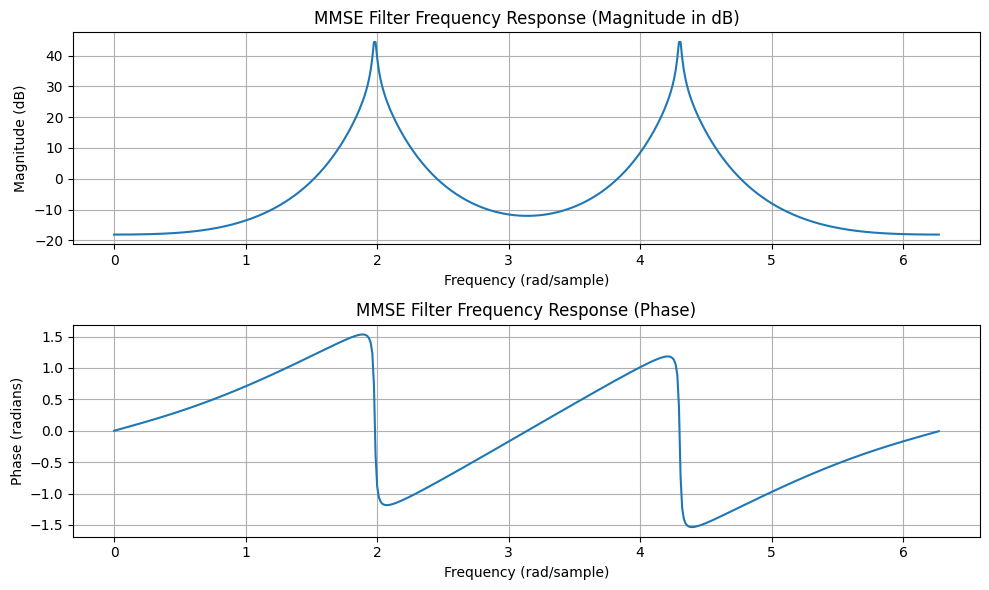

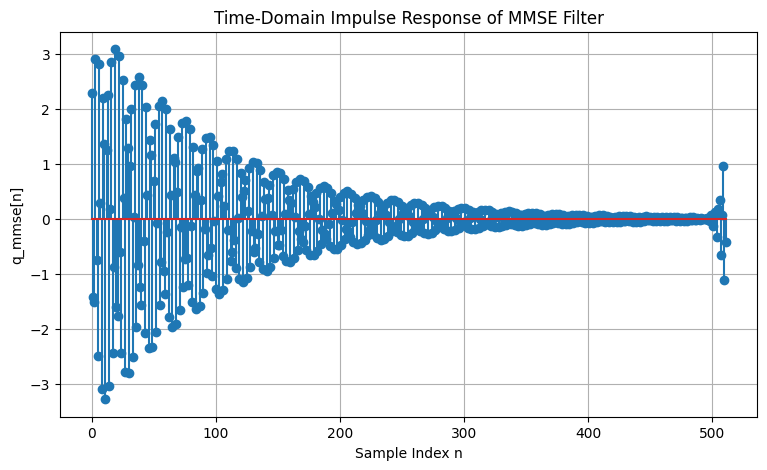

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz

# 1) Define the channel h[n].
h = np.array([1.0, 0.5, 0.75, -2.0/7.0])

# 2) Set the noise standard deviation for MMSE filter
sigma = 0.5  # Adjust this for your desired noise power

# 3) Compute the channel frequency response H(e^{j w})
Nfft = 512
w, Hf = freqz(h, [1.0], worN=Nfft, whole=True)

# 4) Compute the inverse frequency response (1/H(e^{j w}))
Hf_inv = 1 / Hf  # Inverse of the channel frequency response

# 5) Apply the noise adjustment for MMSE filter
den = np.abs(Hf)**2 + sigma**2  # Noise-enhanced term in the denominator
Qf_mmse = Hf_inv / den  # MMSE frequency response

# 6) Convert Q_MMSE(e^{j w}) back to time domain by IFFT
q_mmse_time = np.fft.ifft(Qf_mmse).real  # Take real part of the time-domain filter

# 7) Plot the frequency and time-domain response of the MMSE filter
# Plot Frequency Response (Magnitude and Phase)
Hf_mag_dB = 20 * np.log10(np.abs(Qf_mmse))
Hf_phase = np.angle(Qf_mmse)

plt.figure(figsize=(10, 6))

# Magnitude (dB)
plt.subplot(2, 1, 1)
plt.plot(w, Hf_mag_dB)
plt.title("MMSE Filter Frequency Response (Magnitude in dB)")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid(True)

# Phase
plt.subplot(2, 1, 2)
plt.plot(w, Hf_phase)
plt.title("MMSE Filter Frequency Response (Phase)")
plt.xlabel("Frequency (rad/sample)")
plt.ylabel("Phase (radians)")
plt.grid(True)

plt.tight_layout()
plt.show()

# 8) Plot the Time-Domain Impulse Response of MMSE Filter
plt.figure(figsize=(9, 5))
plt.stem(q_mmse_time)
plt.title("Time-Domain Impulse Response of MMSE Filter")
plt.xlabel("Sample Index n")
plt.ylabel("q_mmse[n]")
plt.grid(True)
plt.show()


In [86]:
import numpy as np
import scipy.signal as spsig
import matplotlib.pyplot as plt

# Constants
sigma = 0.7 # Noise standard deviation
sps = 32  # Samples per symbol (samples per bit)
num_bits = 100  # Number of bits to transmit

# Channel Impulse Response and Inverse Filter
def get_channel_impulse_response():
    """Channel Impulse Response"""
    return np.array([1.0, 0.5, 0.75, -2.0/7.0])

def get_channel_inverse_filter():
    """Inverse Filter"""
    b_inv = np.array([1.0])
    a_inv = np.array([1.0, 0.5, 0.75, -2.0/7.0])
    return b_inv, a_inv

# Pulse Definitions
def half_sine_pulse_time_domain(t, T=1.0):
    """Half-sine pulse over 0 <= t <= T, else 0."""
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)

# Transmit Signal Builder (using half-sine pulse)
def build_half_sine_transmit_signal(bits, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    for i, b in enumerate(bits):
        for idx, tj in enumerate(t_axis):
            tau = tj - i
            val = half_sine_pulse_time_domain(tau, T=1.0)
            x[idx] += b * val
    return t_axis, x

# Detect the bits from the received waveform using a simple thresholding method
def detect_bits(received_signal, sps=32, num_bits=100):
    """
    Detects the bits based on thresholding after matched filtering.
    """
    detected_bits = []
    for i in range(num_bits):
        # Sampling point at the center of each bit period
        sample = received_signal[i * sps + sps // 2]
        detected_bit = 1 if sample > 0 else 0
        detected_bits.append(detected_bit)
    return np.array(detected_bits)

# Simulate the transmission through the noisy channel
def simulate_channel(bits, sps=32, channel_impulse=None, noise_std=0.5):
    if channel_impulse is None:
        channel_impulse = get_channel_impulse_response()
    
    t, x = build_half_sine_transmit_signal(bits, sps=sps)
    
    # Pass through the channel (convolution with channel impulse response)
    y = np.convolve(x, channel_impulse, mode='full')
    y_noisy = y + noise_std * np.random.randn(len(y))
    
    # Apply the inverse filter (before matched filtering)
    b_inv, a_inv = get_channel_inverse_filter()
    y_noisy_inv = spsig.lfilter(b_inv, a_inv, y_noisy)
    
    return y_noisy_inv

# Calculate error between original and reconstructed bits
def calculate_error(original_bits, reconstructed_bits):
    # Compare the original and reconstructed bits and calculate the error rate
    bit_error_rate = np.sum(original_bits != reconstructed_bits) / len(original_bits)
    return bit_error_rate

# Main function to simulate the transmission and reception of random bits
def main():
    # Step 1: Generate a random sequence of bits to transmit
    original_bits = np.random.randint(0, 2, size=num_bits)

    # Step 2: Simulate the transmission of the bits through the channel
    received_signal = simulate_channel(original_bits, sps=sps, noise_std=sigma)
    
    # Step 3: Detect the received bits from the noisy waveform
    detected_bits = detect_bits(received_signal, sps=sps, num_bits=num_bits)
    
    # Step 4: Calculate the error (Bit Error Rate)
    bit_error_rate = calculate_error(original_bits, detected_bits)
    
    print(f'Bit Error Rate (BER): {bit_error_rate * 100:.2f}%')
    
    # Optionally, show the original and detected bits for comparison
    print(f'Original Bits: {original_bits[:10]}...')  # Show first 10 bits
    print(f'Detected Bits: {detected_bits[:10]}...')  # Show first 10 detected bits

if __name__ == "__main__":
    main()


Bit Error Rate (BER): 40.00%
Original Bits: [1 1 1 0 0 1 0 1 0 1]...
Detected Bits: [0 0 1 1 0 1 0 0 0 1]...


In [84]:
import numpy as np
import scipy.signal as spsig
import matplotlib.pyplot as plt

# Constants
sigma = 0  # Noise standard deviation
sps = 32  # Samples per symbol (samples per bit)
num_bits = 100  # Number of bits to transmit
signal_amplification = 2  # Amplify the signal to improve SNR

# Channel Impulse Response and Inverse Filter
def get_channel_impulse_response():
    """Channel Impulse Response"""
    return np.array([1.0, 0.5, 0.75, -2.0/7.0])

def get_channel_inverse_filter():
    """Inverse Filter"""
    b_inv = np.array([1.0])
    a_inv = np.array([1.0, 0.5, 0.75, -2.0/7.0])
    return b_inv, a_inv

# Pulse Definitions
def half_sine_pulse_time_domain(t, T=1.0):
    """Half-sine pulse over 0 <= t <= T, else 0."""
    return np.where((t >= 0) & (t <= T), np.sin(np.pi * t / T), 0.0)

# Transmit Signal Builder (using half-sine pulse)
def build_half_sine_transmit_signal(bits, sps=32):
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    x = np.zeros_like(t_axis)
    
    for i, b in enumerate(bits):
        for idx, tj in enumerate(t_axis):
            tau = tj - i
            val = half_sine_pulse_time_domain(tau, T=1.0)
            x[idx] += b * val
    return t_axis, x

# Matched filter (time-reversed pulse)
def matched_filter(bits, sps=32):
    # Use the half-sine pulse as the matched filter
    N = len(bits)
    dt = 1.0 / sps
    t_end = N
    t_axis = np.arange(0, t_end, dt)
    
    # Create the matched filter as the time-reversed half-sine pulse
    h_mf = np.zeros_like(t_axis)
    
    # Build the matched filter by adding the time-reversed pulse
    for i in range(N):
        tau = t_axis - i
        pulse = half_sine_pulse_time_domain(tau)  # Apply the pulse to each index
        h_mf += pulse * bits[i]  # Adjust for the bit (either 0 or 1)
    
    return h_mf

# Detect the bits from the received waveform using a simple thresholding method
def detect_bits(received_signal, sps=32, num_bits=100):
    detected_bits = []
    for i in range(num_bits):
        # Sampling point at the center of each bit period
        sample = received_signal[i * sps + sps // 2]
        detected_bit = 1 if sample > 0 else 0
        detected_bits.append(detected_bit)
    return np.array(detected_bits)

# Simulate the transmission through the noisy channel with matched filtering
def simulate_channel(bits, sps=32, channel_impulse=None, noise_std=0.5, amplify_signal=1):
    if channel_impulse is None:
        channel_impulse = get_channel_impulse_response()
    
    t, x = build_half_sine_transmit_signal(bits, sps=sps)
    
    # Amplify the signal to improve SNR
    x_amplified = amplify_signal * x
    
    # Pass through the channel (convolution with channel impulse response)
    y = np.convolve(x_amplified, channel_impulse, mode='full')
    
    # Add noise to the signal
    y_noisy = y + noise_std * np.random.randn(len(y))
    
    # Apply the inverse filter (before matched filtering)
    b_inv, a_inv = get_channel_inverse_filter()
    y_noisy_inv = spsig.lfilter(b_inv, a_inv, y_noisy)
    
    # Apply the matched filter
    h_mf = matched_filter(bits, sps)
    y_noisy_inv_mf = np.convolve(y_noisy_inv, h_mf, mode='same')
    
    return y_noisy_inv_mf

# Calculate error between original and reconstructed bits
def calculate_error(original_bits, reconstructed_bits):
    bit_error_rate = np.sum(original_bits != reconstructed_bits) / len(original_bits)
    return bit_error_rate

# Main function to simulate the transmission and reception of random bits
def main():
    original_bits = np.random.randint(0, 2, size=num_bits)  # Generate random bits
    
    # Simulate the transmission of the bits through the channel
    received_signal = simulate_channel(original_bits, sps=sps, noise_std=sigma, amplify_signal=signal_amplification)
    
    # Detect the bits from the received signal
    detected_bits = detect_bits(received_signal, sps=sps, num_bits=num_bits)
    
    # Calculate the error (Bit Error Rate)
    bit_error_rate = calculate_error(original_bits, detected_bits)
    
    print(f'Bit Error Rate (BER): {bit_error_rate * 100:.2f}%')
    print(f'Original Bits (First 10): {original_bits[:10]}...')
    print(f'Detected Bits (First 10): {detected_bits[:10]}...')

if __name__ == "__main__":
    main()


Bit Error Rate (BER): 50.00%
Original Bits (First 10): [0 0 1 0 1 1 0 0 1 1]...
Detected Bits (First 10): [1 1 1 1 1 1 1 1 1 1]...


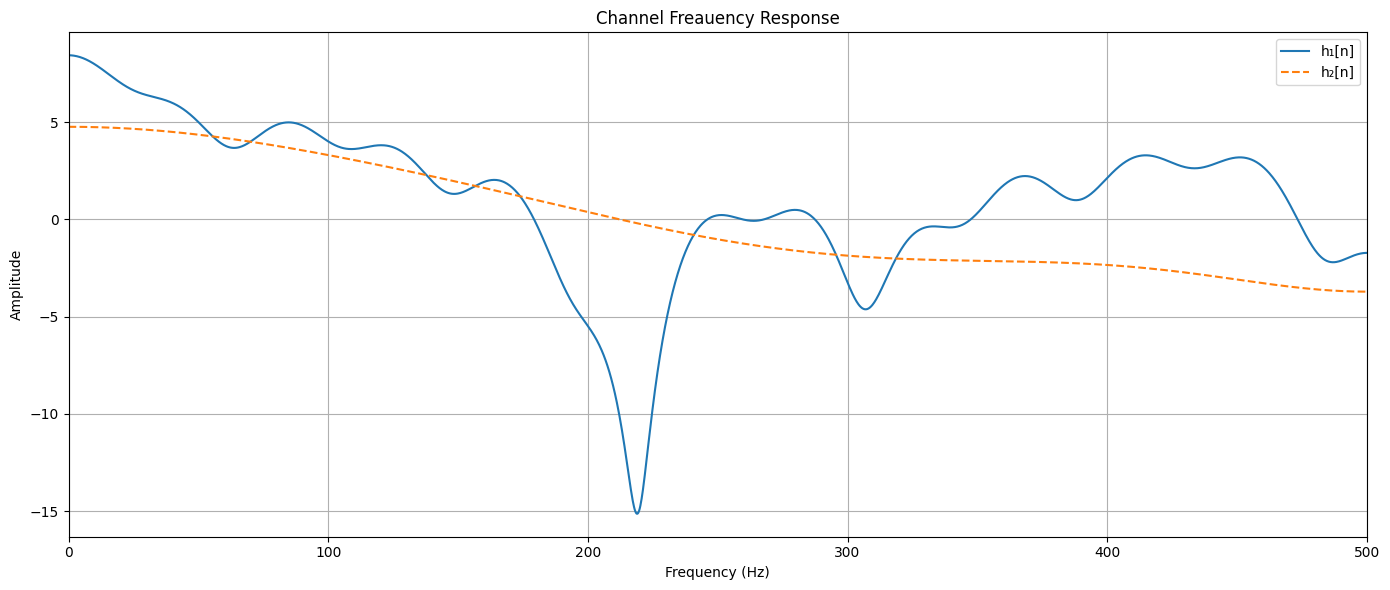

In [40]:
def create_impulse_response():
    # h1[n] (unchanged)
    h1 = np.zeros(26)
    h1[[0, 1, 3, 8, 12, 25]] = [0.5, 1.0, 0.63, 0.25, 0.16, 0.1]
    
    # h2[n] (unchanged)
    h2 = np.zeros(8)
    h2[[0, 1, 2, 3, 5, 7]] = [1.0, 0.4365, 0.1905, 0.0832, 0.01585, 0.003]
    
    return h1, h2

def compute_frequency_response(h, fs=1000, N=4096):
    """
    fs: Sampling frequency in Hz (default = 1000 Hz)
    N: FFT size (default = 4096)
    """
    H = np.fft.fft(h, N)
    freq = np.fft.fftfreq(N, d=1/fs)  # Convert to Hz
    magnitude = 20 * np.log10(np.abs(H))
    return freq, magnitude

# Plot configuration
h1, h2 = create_impulse_response()
fs = 1000  # Set your sampling frequency here (default: 1000 Hz)

# Compute responses
freq1, mag_h1 = compute_frequency_response(h1, fs=fs)
freq2, mag_h2 = compute_frequency_response(h2, fs=fs)

plt.figure(figsize=(14, 6))

plt.plot(freq1[:len(freq1)//2], mag_h1[:len(mag_h1)//2], label='h₁[n]')
plt.plot(freq2[:len(freq2)//2], mag_h2[:len(mag_h2)//2], label='h₂[n]', linestyle='--')
plt.title("Channel Freauency Response")
plt.ylabel("Amplitude")
plt.xlabel("Frequency (Hz)")
plt.xlim(0, fs/2)
plt.grid(True)

plt.legend()
plt.tight_layout()
plt.show()